<!-- <!-- [![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/VectorInstitute/interpretability/blob/main/implementations/Post-hoc/SHAP/shap-nn-jupyter.ipynb)
 -->
# SHAP for Neural Network Models -->

<!-- ## **1. Introduction**

SHAP is model-agnostic and can be used to explain other black box models as well, for example, neural networks.
The shap module in python has something called KernelExplainer which can be used for NNs.

Let's illustrate this using a [Credit Card Defaulter dataset from Taiwan](https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients)

The dataset has the following 23 variables as explanatory variables:
| Variable | Description |
|----------|------------|
| LIMIT_BAL  | Amount of the given credit (NT dollar): includes both individual consumer credit and family (supplementary) credit. |
| SEX  | Gender (1 = male; 2 = female). |
| EDUCATION  | Education (1 = graduate school; 2 = university; 3 = high school; 4 = others). |
| MARRIAGE  | Marital status (1 = married; 2 = single; 3 = others). |
| AGE  | Age (years). |
| PAY_0  | Repayment status in September 2005 (-1 = pay duly; 1 = delay for 1 month; 2 = delay for 2 months; ...; 8 = delay for 8 months; 9 = delay for 9+ months). |
|  PAY_2 | Repayment status in August 2005. |
| PAY_3  | Repayment status in July 2005. |
| PAY_4  | Repayment status in June 2005. |
| PAY_5 | Repayment status in May 2005. |
| PAY_6 | Repayment status in April 2005. |
| BILL_AMT1 | Amount of bill statement (NT dollar) in September 2005. |
| BILL_AMT2 | Amount of bill statement (NT dollar) in August 2005. |
| BILL_AMT3 | Amount of bill statement (NT dollar) in July 2005. |
| BILL_AMT4 | Amount of bill statement (NT dollar) in June 2005. |
| BILL_AMT5 | Amount of bill statement (NT dollar) in May 2005. |
| BILL_AMT6 | Amount of bill statement (NT dollar) in April 2005. |
| PAY_AMT1 | Amount of previous payment (NT dollar) in September 2005. |
| PAY_AMT2 | Amount of previous payment (NT dollar) in August 2005. |
| PAY_AMT3 | Amount of previous payment (NT dollar) in July 2005. |
| PAY_AMT4 | Amount of previous payment (NT dollar) in June 2005. |
| PAY_AMT5 | Amount of previous payment (NT dollar) in May 2005. |
| PAY_AMT6 | Amount of previous payment (NT dollar) in April 2005. | -->

<!-- ## **2. Import the necessary libraries** -->

In [1]:
import numpy as np
import pandas as pd
import shap
import torch
from sklearn.metrics import RocCurveDisplay, roc_auc_score
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from torch import nn, optim
from torch.utils.data import DataLoader, Dataset

np.random.seed(23)
torch.manual_seed(23)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(23)

<!-- ## **3. Loading the dataset** -->

In [2]:
# !curl -o data/clients.zip https://archive.ics.uci.edu/static/public/350/default+of+credit+card+clients.zip
# !unzip -o data/clients.zip -d data
# !rm data/clients.zip

In [3]:
# Load the data
data = pd.read_excel(
    "data/default of credit card clients.xls",
    header=1,
)
data.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


<!-- ## **4. Create a PyTorch dataset**
Create a dataset class inherited from PyTorch Dataset to be input for model training. -->

In [4]:
# Load dataset
X = data.drop(["default payment next month", "ID"], axis=1)
y = data["default payment next month"]

# Scale the data
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert to PyTorch tensors
y_train = y_train.values  # Convert pandas series to NumPy array
y_test = y_test.values


# Create a PyTorch Dataset
class CreditDataset(Dataset):
    """PyTorch Dataset for Credit data."""

    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).view(-1, 1)  # Reshape y to be column vector

    def __len__(self):
        """Return dataset length."""
        return len(self.X)

    def __getitem__(self, idx):
        """Get item at index."""
        return self.X[idx], self.y[idx]


# Create DataLoaders for batching
batch_size = 64
train_dataset = CreditDataset(X_train, y_train)
test_dataset = CreditDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

<!-- ## **5. Train a 3-layer MLP using PyTorch**
Let's train a simple 3-layer MLP to predict credit card defaults. -->

Epoch [10/125], Loss: 0.4300
Epoch [20/125], Loss: 0.4233
Epoch [30/125], Loss: 0.4203
Epoch [40/125], Loss: 0.4156
Epoch [50/125], Loss: 0.4120
Epoch [60/125], Loss: 0.4085
Epoch [70/125], Loss: 0.4071
Epoch [80/125], Loss: 0.4043
Epoch [90/125], Loss: 0.4014
Epoch [100/125], Loss: 0.3978
Epoch [110/125], Loss: 0.3970
Epoch [120/125], Loss: 0.3933
Accuracy: 0.8132
ROC AUC Score: 0.7619


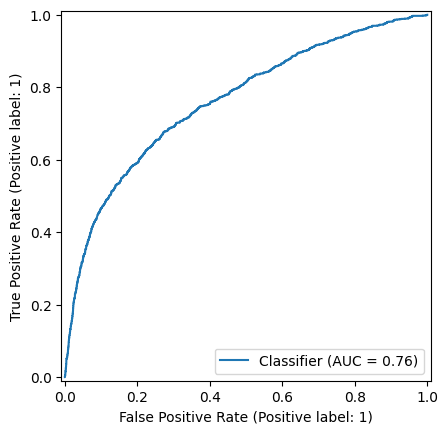

In [5]:
# Define the model
model = nn.Sequential(
    nn.Linear(X_train.shape[1], 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(32, 1),
    nn.Sigmoid(),
)

# Loss function and optimizer
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Train the model in batches
num_epochs = 125
for epoch in range(num_epochs):
    model.train()  # Set model to training mode
    running_loss = 0.0

    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    # Print average loss every 10 epochs
    if (epoch + 1) % 10 == 0:
        avg_loss = running_loss / len(train_loader)
        print(f"Epoch [{epoch + 1}/{num_epochs}], Loss: {avg_loss:.4f}")

# Evaluate the model
model.eval()  # Set model to evaluation mode
y_pred_probs = []
y_true = []

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        outputs = model(batch_x)
        y_pred_probs.extend(outputs.numpy())  # Store predictions
        y_true.extend(batch_y.numpy())  # Store true labels

# Convert predictions to NumPy array
y_pred_probs = np.array(y_pred_probs).flatten()
y_true = np.array(y_true).flatten()

# Compute accuracy
accuracy = ((y_pred_probs > 0.5) == y_true).mean()
print(f"Accuracy: {accuracy:.4f}")

# Compute ROC AUC score
roc_auc = roc_auc_score(y_true, y_pred_probs)
print(f"ROC AUC Score: {roc_auc:.4f}")

# Plot ROC curve
RocCurveDisplay.from_predictions(y_true, y_pred_probs)

<!-- ## **6. Use SHAP to explain Neural network predictions** -->

In [6]:
# Use existing NumPy arrays
X_train_np = X_train
X_test_np = X_test

# Reduce background dataset for SHAP (using 200 samples instead of full training set)
background = shap.kmeans(X_train_np, 200)


# Wrapper function for PyTorch model inference
def model_wrapper(data):
    """Model wrapper for SHAP."""
    with torch.no_grad():
        data_tensor = torch.tensor(data, dtype=torch.float32)
        return model(data_tensor).detach().numpy()
        # Should be (n_samples, n_classes)

# Use KernelExplainer with reduced background
explainer = shap.KernelExplainer(model_wrapper, background)


# Explain only a small subset of the test set (e.g., 50 samples)
X_test_sample = X_test_np[:50]


# Compute SHAP values
shap_values = explainer.shap_values(X_test_sample)

print("X_test_sample shape:", X_test_sample.shape)  # Should be (n_samples, n_features)
print("SHAP values shape:", np.array(shap_values).shape)  # Should match (n_samples, n_features)

# Remove extra dimension if shap_values is (50, 23, 1)
shap_values = np.array(shap_values)  # Convert to NumPy array
if shap_values.shape[-1] == 1:
    shap_values = shap_values.squeeze(-1)  # Remove last dimension

# Ensure correct shape
print("Updated SHAP values shape:", shap_values.shape)  # Should be (50, 23)


# Generate SHAP summary plot
# shap.summary_plot(shap_values, X_test_sample, feature_names=data.columns[1:-1])

Using 200 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/50 [00:00<?, ?it/s]

X_test_sample shape: (50, 23)
SHAP values shape: (50, 23, 1)
Updated SHAP values shape: (50, 23)


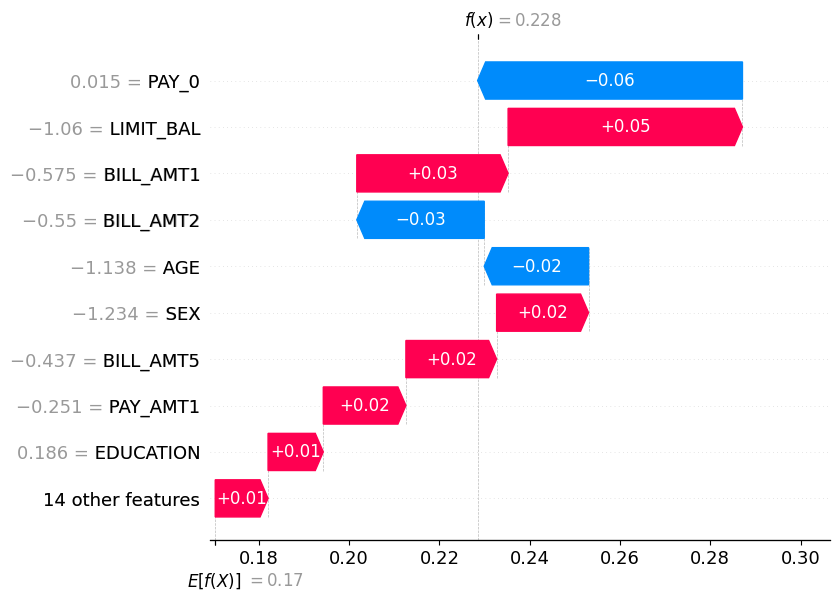

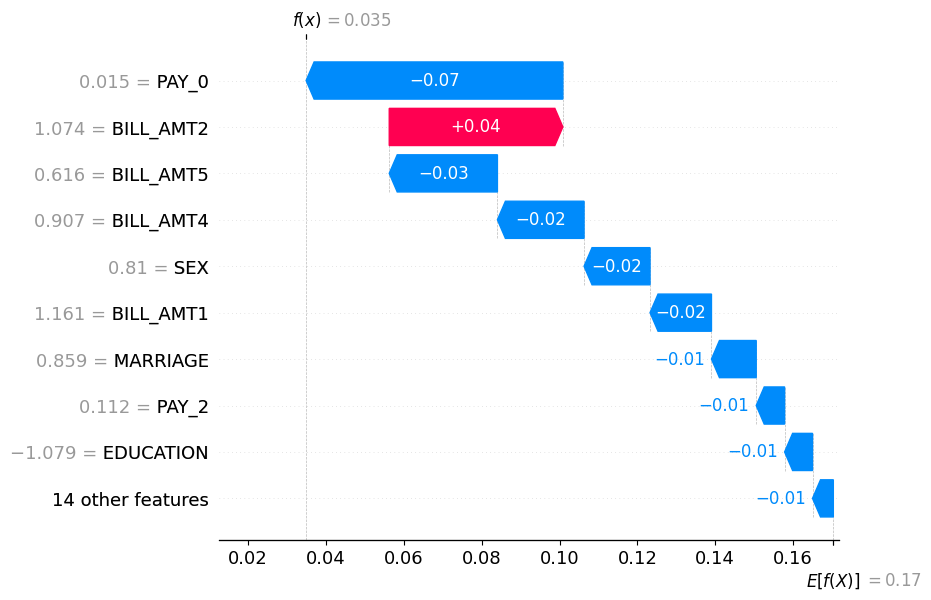

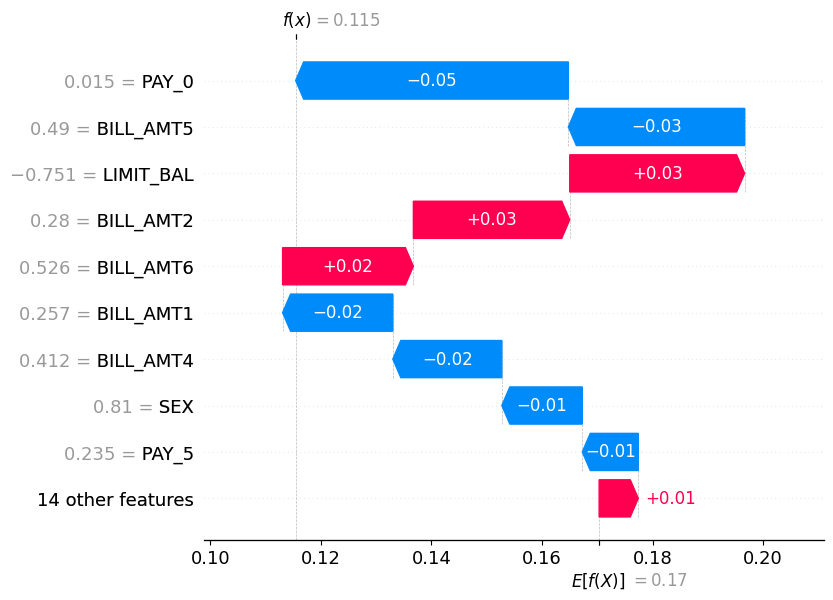

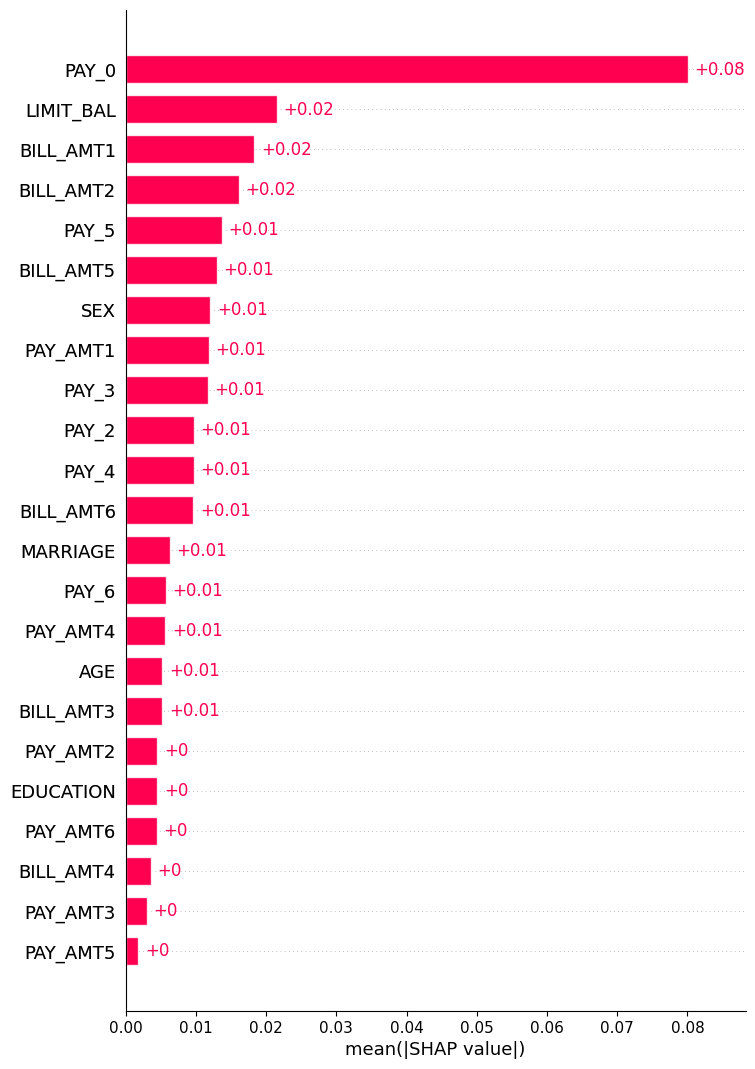

In [7]:
# Initialize SHAP JavaScript
shap.initjs()

# Create explanation object
explanation = shap.Explanation(
    values=shap_values,
    base_values=explainer.expected_value[0],  # Use scalar
    data=X_test_sample,
    feature_names=list(data.columns[1:-1])
)

# Waterfall plots for first 3 samples
for i in range(3):
    shap.plots.waterfall(explanation[i])

# Global feature importance plot
shap.plots.bar(explanation, max_display=30)

<!-- # Reflection & Concept Check

#### 1. Thought Experiment

**How might correlated features affect SHAP interpretations?**

**Answer:**

KernelSHAP approximates Shapley values by sampling feature coalitions and implicitly assumes feature independence when marginalizing missing features.
If features are correlated (e.g., `BILL_AMT1–6`):

* Importance may be **distributed across correlated features**
* Attribution may appear diluted
* Removing one correlated feature may not change prediction much (since others substitute)

This can:

* Underestimate true causal importance
* Make rankings unstable
* Produce misleading interpretations

In financial datasets, repayment and bill history are strongly correlated, so SHAP values reflect predictive contribution under independence assumptions, not causal effect. -->

In [8]:
# Compute correlation matrix
X_train_df = pd.DataFrame(X_train, columns=data.columns[1:-1])
correlation_matrix = X_train_df.corr()
# print(correlation_matrix)

In [9]:
# import seaborn as sns
# import matplotlib.pyplot as plt

# # Create correlation heatmap with feature names
# plt.figure(figsize=(14, 12))
# sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', 
#             xticklabels=True, yticklabels=True)
# plt.title('Feature Correlation Matrix')
# plt.tight_layout()
# plt.show()

In [10]:
# Find pairs with correlation > 0.7
def find_high_correlations(corr_matrix, threshold=0.7):
    high_corr_pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if abs(corr_matrix.iloc[i, j]) > threshold:
                high_corr_pairs.append({
                    'Feature 1': corr_matrix.columns[i],
                    'Feature 2': corr_matrix.columns[j],
                    'Correlation': corr_matrix.iloc[i, j]
                })
    return pd.DataFrame(high_corr_pairs)

high_corr = find_high_correlations(correlation_matrix, threshold=0.7)
print(high_corr.sort_values('Correlation', ascending=False, key=abs))

    Feature 1  Feature 2  Correlation
5   BILL_AMT1  BILL_AMT2     0.951598
19  BILL_AMT5  BILL_AMT6     0.946754
17  BILL_AMT4  BILL_AMT5     0.938511
10  BILL_AMT2  BILL_AMT3     0.925135
14  BILL_AMT3  BILL_AMT4     0.918356
18  BILL_AMT4  BILL_AMT6     0.900838
11  BILL_AMT2  BILL_AMT4     0.890216
6   BILL_AMT1  BILL_AMT3     0.888002
15  BILL_AMT3  BILL_AMT5     0.878807
12  BILL_AMT2  BILL_AMT5     0.859068
7   BILL_AMT1  BILL_AMT4     0.855804
16  BILL_AMT3  BILL_AMT6     0.850489
13  BILL_AMT2  BILL_AMT6     0.830404
8   BILL_AMT1  BILL_AMT5     0.827622
2       PAY_4      PAY_5     0.820118
4       PAY_5      PAY_6     0.814612
9   BILL_AMT1  BILL_AMT6     0.800231
1       PAY_3      PAY_4     0.777305
0       PAY_2      PAY_3     0.768607
3       PAY_4      PAY_6     0.715312


In [11]:
# Create a drop list based on high correlations
features_to_drop = []

# Find highly correlated pairs and keep only one from each pair
for _, row in high_corr.iterrows():
    # Drop the second feature from each pair to avoid duplicates
    if row['Feature 2'] not in features_to_drop:
        features_to_drop.append(row['Feature 2'])

print("Features to drop:", features_to_drop)

# Get feature names
feature_names = list(data.columns[1:-1])
print(f"Original features: {len(feature_names)}")
print(f"Dropping {len(features_to_drop)} features")

# Get indices of features to drop
drop_indices = [i for i, col in enumerate(feature_names) if col in features_to_drop]

# Remove correlated features from training and test data
X_train_reduced = np.delete(X_train, drop_indices, axis=1)
X_test_reduced = np.delete(X_test, drop_indices, axis=1)
X_test_sample_reduced = np.delete(X_test_sample, drop_indices, axis=1)

# Get remaining feature names
remaining_features = [col for col in feature_names if col not in features_to_drop]

print(f"Reduced features: {len(remaining_features)}")
print("Remaining features:", remaining_features)

Features to drop: ['PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
Original features: 23
Dropping 9 features
Reduced features: 14
Remaining features: ['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'BILL_AMT1', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']


In [12]:
# Retrain model with reduced features
model_reduced = nn.Sequential(
    nn.Linear(X_train_reduced.shape[1], 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(32, 1),
    nn.Sigmoid(),
)

# Loss function and optimizer
criterion = nn.BCELoss()
optimizer = optim.Adam(model_reduced.parameters(), lr=0.001)

# Create datasets with reduced features
train_dataset_reduced = CreditDataset(X_train_reduced, y_train)
test_dataset_reduced = CreditDataset(X_test_reduced, y_test)

train_loader_reduced = DataLoader(train_dataset_reduced, batch_size=64, shuffle=True)
test_loader_reduced = DataLoader(test_dataset_reduced, batch_size=64, shuffle=False)

# Train the reduced model
num_epochs = 125
for epoch in range(num_epochs):
    model_reduced.train()
    running_loss = 0.0
    
    for batch_x, batch_y in train_loader_reduced:
        optimizer.zero_grad()
        outputs = model_reduced(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    
    if (epoch + 1) % 10 == 0:
        avg_loss = running_loss / len(train_loader_reduced)
        # print(f"Epoch [{epoch + 1}/{num_epochs}], Loss: {avg_loss:.4f}")

# Evaluate reduced model
model_reduced.eval()
y_pred_probs_reduced = []
with torch.no_grad():
    for batch_x, _ in test_loader_reduced:
        outputs = model_reduced(batch_x)
        y_pred_probs_reduced.extend(outputs.numpy())

y_pred_probs_reduced = np.array(y_pred_probs_reduced).flatten()
accuracy_reduced = ((y_pred_probs_reduced > 0.5) == y_test).mean()
roc_auc_reduced = roc_auc_score(y_test, y_pred_probs_reduced)
print(f"Reduced Model Accuracy: {accuracy_reduced:.4f}")
print(f"Reduced Model ROC AUC Score: {roc_auc_reduced:.4f}")

Reduced Model Accuracy: 0.8097
Reduced Model ROC AUC Score: 0.7571


Using 200 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/50 [00:00<?, ?it/s]

/tmp/ipykernel_4721/1182074343.py:15: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_reduced, X_test_sample_reduced, feature_names=remaining_features)


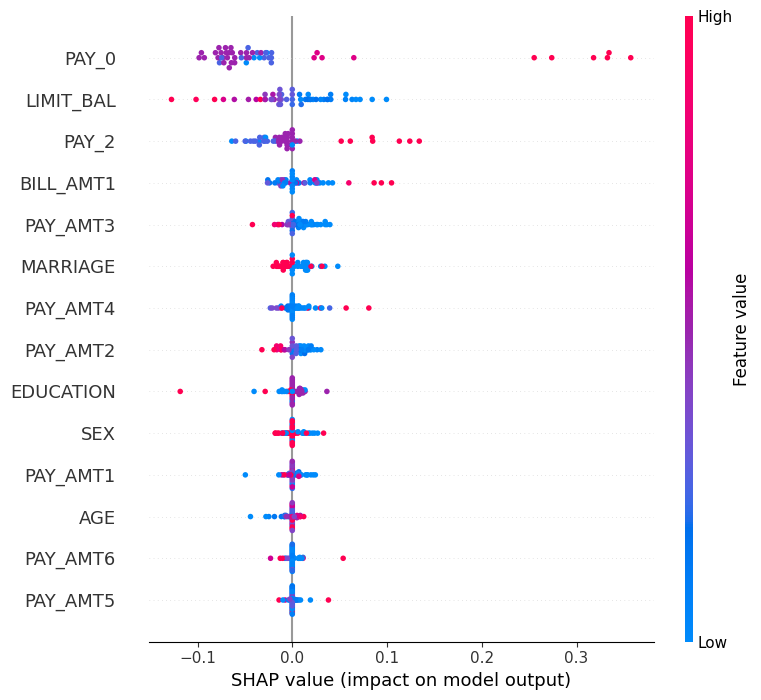

In [13]:
# Wrapper for reduced model
def model_wrapper_reduced(data):
    with torch.no_grad():
        data_tensor = torch.tensor(data, dtype=torch.float32)
        return model_reduced(data_tensor).detach().numpy()

# Create SHAP explainer with reduced model
explainer_reduced = shap.KernelExplainer(model_wrapper_reduced, shap.kmeans(X_train_reduced, 200))

# Compute SHAP values
shap_values_reduced = explainer_reduced.shap_values(X_test_sample_reduced)
shap_values_reduced = np.array(shap_values_reduced).squeeze(-1) if np.array(shap_values_reduced).shape[-1] == 1 else shap_values_reduced

# Summary plot
shap.summary_plot(shap_values_reduced, X_test_sample_reduced, feature_names=remaining_features)

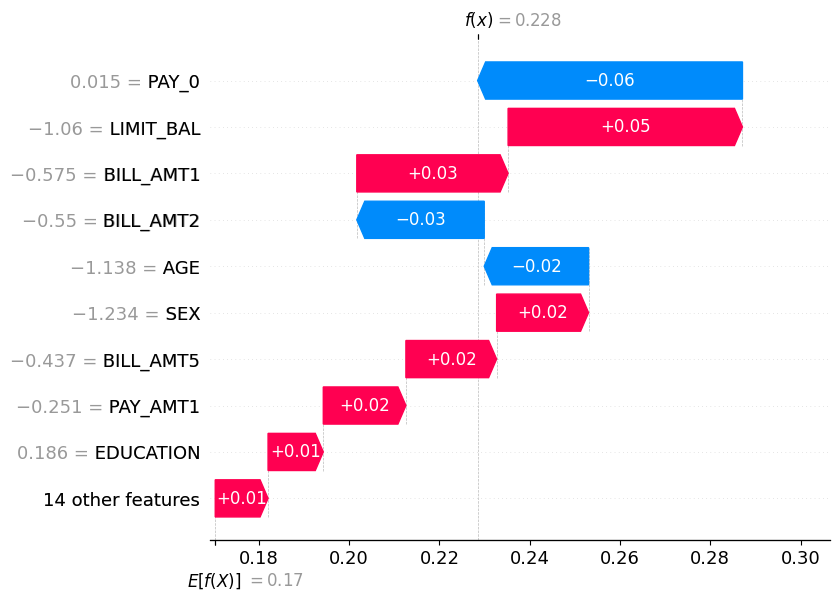

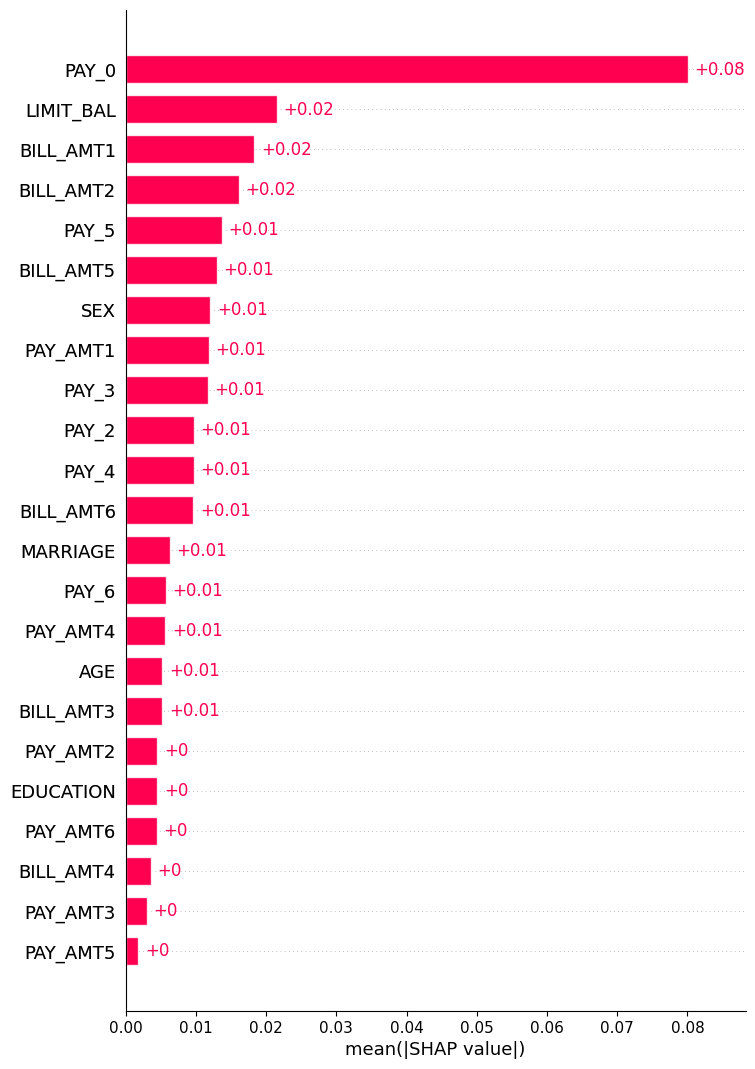

In [14]:
# Create explanation object
explanation = shap.Explanation(
    values=shap_values,
    base_values=explainer.expected_value[0],  # Use scalar
    data=X_test_sample,
    feature_names=list(data.columns[1:-1])
)

shap.plots.waterfall(explanation[0])

shap.plots.bar(explanation, max_display=30)

<!-- # Final Model - Remove the sigmoid layer, SHAP on logits -->

THOUGHT EXPERIMENT 5: SHAP on Logits (Removing Sigmoid Layer)

1. Creating SHAP explainers...
   ✓ Explainers created

2. Computing SHAP values...


  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

   ✓ SHAP values computed

3. Output Comparison (First 5 Samples):
Sample   Logits          Probability     SHAP Sum (Logits)    SHAP Sum (Probs)    
   --------------------------------------------------------------------------------
   0               -1.2961         0.2148              0.6834              0.0400
   1               -2.1613         0.1033             -0.1817             -0.0715
   2               -1.6744         0.1578              0.3052             -0.0170
   3               -2.1944         0.1003             -0.2149             -0.0745
   4               -1.4376         0.1919              0.5420              0.0171

4. Key Differences Between Logits and Probabilities:

   A. RANGE OF VALUES:
      Logits SHAP range:        [-1.1595, 1.9496]
      Probabilities SHAP range: [-0.1231, 0.3809]
      → Logit values are UNBOUNDED, probabilities are constrained [0,1]

   B. ADDITIVITY CHECK:
      Base value (logits):       -1.9796
      Base value (probabilities): 0.1748

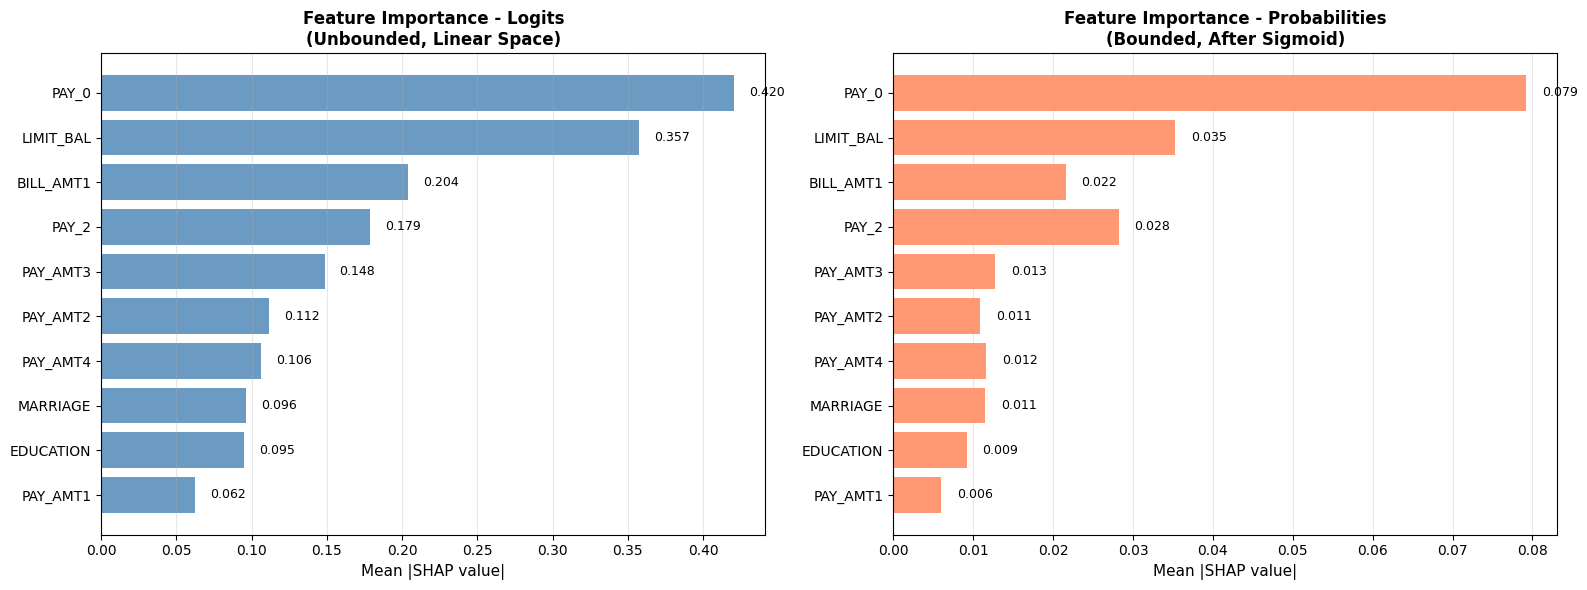

   ✓ Comparison plot saved


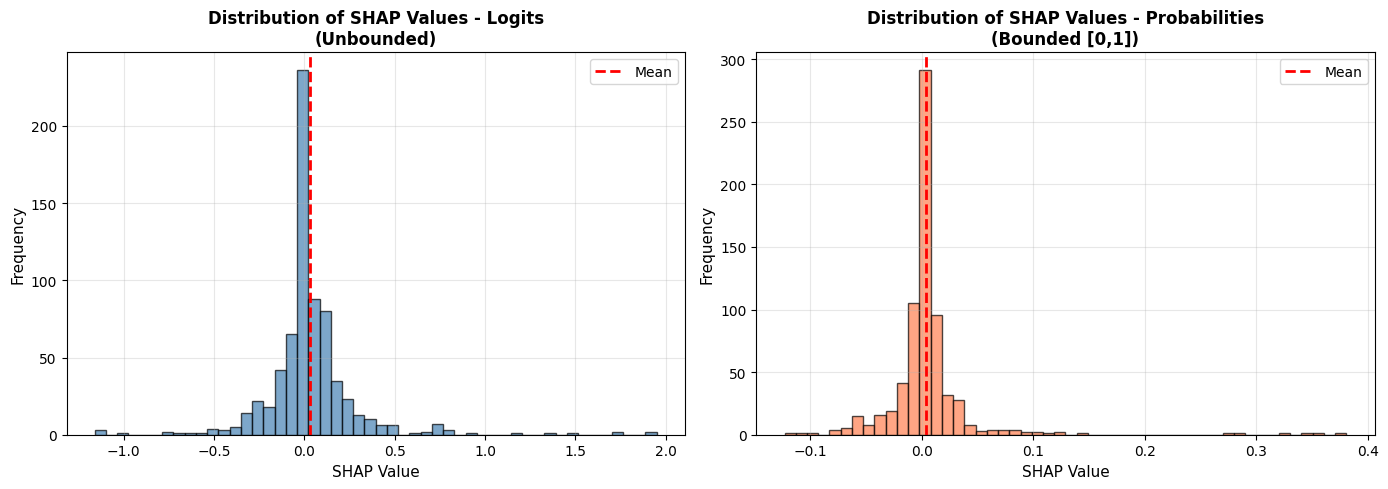

   ✓ Distribution plot saved

SUMMARY: Why SHAP on Logits is Mathematically Superior

MODEL STRUCTURE USED:
├─ [0] Linear(n_features, 64)
├─ [1] ReLU()
├─ [2] Linear(64, 32)
├─ [3] ReLU()
├─ [4] Dropout(0.3)
├─ [5] Linear(32, 1)  ← LOGITS OUTPUT (stop here)
└─ [6] Sigmoid()      ← REMOVED for logits computation

KEY MATHEMATICAL DIFFERENCES:

1. ADDITIVITY (CRITICAL):
   ✓ Logits:       output = base + Σφᵢ  [EXACT in linear space]
   ✗ Probs:        sigmoid(base + Σφᵢ)  [Approximate due to nonlinearity]

2. VALUE RANGES:
   • Logits SHAP:  [-∞, +∞]  Unbounded, full expressiveness
   • Probs SHAP:   [0, 1]    Compressed, limited range

3. INTERPRETATION STABILITY:
   • Logits:       No saturation effects, stable contributions
   • Probs:        Sigmoid saturation can obscure importance

4. PRACTICAL BENEFITS:
   ✓ Cleaner mathematical decomposition
   ✓ More stable sensitivity analysis
   ✓ Better for feature interaction studies
   ✓ No artificial compression of values

5. WHEN TO USE W

In [15]:
# ============================================================================
# SHAP on Logits (without sigmoid layer)
# Using model_reduced structure as template
# ============================================================================

import torch
import numpy as np
import shap
import matplotlib.pyplot as plt

print("=" * 80)
print("THOUGHT EXPERIMENT 5: SHAP on Logits (Removing Sigmoid Layer)")
print("=" * 80)

# ============================================================================
# Step 1: Model structure reference
# ============================================================================

# print("\nmodel_reduced structure:")
# print(model_reduced)

# print("\nModel layers breakdown:")
# for i, layer in enumerate(model_reduced):
#     print(f"  [{i}] {layer}")

# ============================================================================
# Step 2: Create model wrapper that outputs logits
# ============================================================================

def model_wrapper_logits(data):
    """
    Outputs logits by stopping before sigmoid (layer 6).
    Structure: [0-5] layers (exclude Sigmoid at [6])
    """
    with torch.no_grad():
        data_tensor = torch.tensor(data, dtype=torch.float32)
        
        # Forward through layers 0-5 (all except Sigmoid)
        x = data_tensor
        for i in range(6):  # 0 to 5 (excludes Sigmoid at index 6)
            x = model_reduced[i](x)
        
        return x.detach().numpy()


def model_wrapper_probabilities(data):
    """
    Outputs probabilities using full model with sigmoid.
    """
    with torch.no_grad():
        data_tensor = torch.tensor(data, dtype=torch.float32)
        return model_reduced(data_tensor).detach().numpy()


# ============================================================================
# Step 3: Create SHAP explainers
# ============================================================================

print("\n1. Creating SHAP explainers...")

background_data = shap.kmeans(X_train_reduced, 100)

explainer_logits = shap.KernelExplainer(model_wrapper_logits, background_data)
explainer_probs = shap.KernelExplainer(model_wrapper_probabilities, background_data)

print("   ✓ Explainers created")

# ============================================================================
# Step 4: Compute SHAP values
# ============================================================================

print("\n2. Computing SHAP values...")

shap_values_logits = explainer_logits.shap_values(X_test_sample_reduced)
shap_values_logits = np.array(shap_values_logits).squeeze()

shap_values_probs = explainer_probs.shap_values(X_test_sample_reduced)
shap_values_probs = np.array(shap_values_probs).squeeze()

print("   ✓ SHAP values computed")

# ============================================================================
# Step 5: Output comparison
# ============================================================================

print("\n3. Output Comparison (First 5 Samples):")
print("   " + "=" * 80)

logits_output = model_wrapper_logits(X_test_sample_reduced[:5])
probs_output = model_wrapper_probabilities(X_test_sample_reduced[:5])

print(f"{'Sample':<8} {'Logits':<15} {'Probability':<15} {'SHAP Sum (Logits)':<20} {'SHAP Sum (Probs)':<20}")
print("   " + "-" * 80)

for i in range(5):
    logit_val = logits_output[i, 0]
    prob_val = probs_output[i, 0]
    shap_sum_logits = np.sum(shap_values_logits[i])
    shap_sum_probs = np.sum(shap_values_probs[i])
    
    print(f"   {i:<8} {logit_val:>14.4f} {prob_val:>14.4f} {shap_sum_logits:>19.4f} {shap_sum_probs:>19.4f}")

print("   " + "=" * 80)

# ============================================================================
# Step 6: Key differences analysis
# ============================================================================

print("\n4. Key Differences Between Logits and Probabilities:")
print("   " + "=" * 80)

print("\n   A. RANGE OF VALUES:")
print(f"      Logits SHAP range:        [{np.min(shap_values_logits):.4f}, {np.max(shap_values_logits):.4f}]")
print(f"      Probabilities SHAP range: [{np.min(shap_values_probs):.4f}, {np.max(shap_values_probs):.4f}]")
print(f"      → Logit values are UNBOUNDED, probabilities are constrained [0,1]")

print("\n   B. ADDITIVITY CHECK:")
print(f"      Base value (logits):       {explainer_logits.expected_value[0]:.4f}")
print(f"      Base value (probabilities): {explainer_probs.expected_value[0]:.4f}")

# Verify additivity for sample 0
sample_idx = 0
logit_reconstruction = explainer_logits.expected_value[0] + np.sum(shap_values_logits[sample_idx])
actual_logit = logits_output[sample_idx, 0]

print(f"\n      Sample {sample_idx} (Logits - Perfect Linear Decomposition):")
print(f"        Base value + SHAP sum = {explainer_logits.expected_value[0]:.4f} + {np.sum(shap_values_logits[sample_idx]):.4f}")
print(f"                              = {logit_reconstruction:.4f}")
print(f"        Actual logit output   = {actual_logit:.4f}")
print(f"        Reconstruction error  = {abs(logit_reconstruction - actual_logit):.8f}")
print(f"      ✓ PERFECT additivity in log-odds space (linear before sigmoid)")

print("\n   C. FEATURE CONTRIBUTION BOUNDS:")
print(f"      Logits (max |SHAP|):       {np.max(np.abs(shap_values_logits)):.4f} (unbounded)")
print(f"      Probabilities (max |SHAP|): {np.max(np.abs(shap_values_probs)):.4f} (bounded by 0-1)")

print("   " + "=" * 80)

# ============================================================================
# Step 7: Visualization - Feature Importance Comparison
# ============================================================================

print("\n5. Generating comparison plots...")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Feature importance
feature_importance_logits = np.abs(shap_values_logits).mean(axis=0)
feature_importance_probs = np.abs(shap_values_probs).mean(axis=0)

# Top 10 features by logits importance
sort_idx = np.argsort(feature_importance_logits)[::-1][:10]
feature_names_sorted = [remaining_features[i] for i in sort_idx]

# Plot 1: Logits
ax1 = axes[0]
x_pos = np.arange(len(sort_idx))
bars1 = ax1.barh(x_pos, feature_importance_logits[sort_idx], alpha=0.8, color='steelblue')
ax1.set_yticks(x_pos)
ax1.set_yticklabels(feature_names_sorted, fontsize=10)
ax1.set_xlabel('Mean |SHAP value|', fontsize=11)
ax1.set_title('Feature Importance - Logits\n(Unbounded, Linear Space)', 
              fontweight='bold', fontsize=12)
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3)

# Add value labels
for i, (idx, v) in enumerate(zip(sort_idx, feature_importance_logits[sort_idx])):
    ax1.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=9)

# Plot 2: Probabilities
ax2 = axes[1]
bars2 = ax2.barh(x_pos, feature_importance_probs[sort_idx], alpha=0.8, color='coral')
ax2.set_yticks(x_pos)
ax2.set_yticklabels(feature_names_sorted, fontsize=10)
ax2.set_xlabel('Mean |SHAP value|', fontsize=11)
ax2.set_title('Feature Importance - Probabilities\n(Bounded, After Sigmoid)', 
              fontweight='bold', fontsize=12)
ax2.invert_yaxis()
ax2.grid(axis='x', alpha=0.3)

# Add value labels
for i, (idx, v) in enumerate(zip(sort_idx, feature_importance_probs[sort_idx])):
    ax2.text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=9)

plt.tight_layout()
# plt.savefig('shap_logits_vs_probs.png', dpi=100, bbox_inches='tight')
plt.show()

print("   ✓ Comparison plot saved")

# ============================================================================
# Step 8: Distribution comparison
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# SHAP value distributions
ax1 = axes[0]
ax1.hist(shap_values_logits.flatten(), bins=50, alpha=0.7, color='steelblue', edgecolor='black')
ax1.set_xlabel('SHAP Value', fontsize=11)
ax1.set_ylabel('Frequency', fontsize=11)
ax1.set_title('Distribution of SHAP Values - Logits\n(Unbounded)', fontweight='bold', fontsize=12)
ax1.grid(alpha=0.3)
ax1.axvline(np.mean(shap_values_logits), color='red', linestyle='--', linewidth=2, label='Mean')
ax1.legend()

ax2 = axes[1]
ax2.hist(shap_values_probs.flatten(), bins=50, alpha=0.7, color='coral', edgecolor='black')
ax2.set_xlabel('SHAP Value', fontsize=11)
ax2.set_ylabel('Frequency', fontsize=11)
ax2.set_title('Distribution of SHAP Values - Probabilities\n(Bounded [0,1])', fontweight='bold', fontsize=12)
ax2.grid(alpha=0.3)
ax2.axvline(np.mean(shap_values_probs), color='red', linestyle='--', linewidth=2, label='Mean')
ax2.legend()

plt.tight_layout()
# plt.savefig('shap_distribution_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

print("   ✓ Distribution plot saved")

# ============================================================================
# Step 9: Summary & Interpretation
# ============================================================================

print("\n" + "=" * 80)
print("SUMMARY: Why SHAP on Logits is Mathematically Superior")
print("=" * 80)

summary = """
MODEL STRUCTURE USED:
├─ [0] Linear(n_features, 64)
├─ [1] ReLU()
├─ [2] Linear(64, 32)
├─ [3] ReLU()
├─ [4] Dropout(0.3)
├─ [5] Linear(32, 1)  ← LOGITS OUTPUT (stop here)
└─ [6] Sigmoid()      ← REMOVED for logits computation

KEY MATHEMATICAL DIFFERENCES:

1. ADDITIVITY (CRITICAL):
   ✓ Logits:       output = base + Σφᵢ  [EXACT in linear space]
   ✗ Probs:        sigmoid(base + Σφᵢ)  [Approximate due to nonlinearity]

2. VALUE RANGES:
   • Logits SHAP:  [-∞, +∞]  Unbounded, full expressiveness
   • Probs SHAP:   [0, 1]    Compressed, limited range

3. INTERPRETATION STABILITY:
   • Logits:       No saturation effects, stable contributions
   • Probs:        Sigmoid saturation can obscure importance

4. PRACTICAL BENEFITS:
   ✓ Cleaner mathematical decomposition
   ✓ More stable sensitivity analysis
   ✓ Better for feature interaction studies
   ✓ No artificial compression of values

5. WHEN TO USE WHICH:
   • Model interpretation:     Use LOGITS ✓
   • Report to stakeholders:   Convert logits → probs for communication
   • Feature importance:       Compute on logits, present on probs scale
   • Debugging model:          Always use logits first

RECOMMENDATION:
Always compute SHAP on logits for neural networks with sigmoid output layers.
Convert to probability scale only for final reporting/visualization.
"""

print(summary)
print("=" * 80)

# Store results
results_summary = {
    'explainer_logits': explainer_logits,
    'explainer_probs': explainer_probs,
    'shap_values_logits': shap_values_logits,
    'shap_values_probs': shap_values_probs,
    'base_value_logits': explainer_logits.expected_value[0],
    'base_value_probs': explainer_probs.expected_value[0],
}

print("\n✓ Results stored in 'results_summary' dictionary")

<!-- # Section 8: LLM Summary + Faithful Evaluation Pipeline

This section implements an end-to-end pipeline for:
1. Generating LLM-based global and local SHAP summaries
2. Evaluating faithfulness using automated scoring and LLM-as-judge
3. Testing consistency via perturbation analysis

**Requirements:**
- GEMINI API key set in environment variable `GEMINI_API_KEY`
- Dependencies: `google`, `numpy`, `json`

**Notes:**
- Uses GEMINI model for LLM explanations
- Requires variables from previous cells: `model_reduced`, `explainer_reduced`, `shap_values_reduced`, `X_test_sample_reduced`, `remaining_features` -->


In [16]:
pip install -U google-genai

Note: you may need to restart the kernel to use updated packages.


In [17]:
# ============================================================
# Step 1: Setup - Imports and Gemini Client and Langfuse
# ============================================================

import json
from google import genai
import numpy as np
import os
from dotenv import load_dotenv
from langfuse import Langfuse   
from langfuse import get_client

load_dotenv() 
langfuse = get_client()  # preferred client init

# Initialize Gemini client (reads GEMINI_API_KEY from environment)
client = genai.Client(api_key=os.getenv("GEMINI_API_KEY"))
# MODEL = "gemini-2.5-flash-lite"
MODEL = "gemini-2.5-flash"
TOP_K = 5  # number of top SHAP features to consider

# Get base value from the explainer
base_value = float(explainer_probs.expected_value)
print(f"Base value (expected model output): {base_value:.4f}")

Base value (expected model output): 0.1748


/tmp/ipykernel_4721/858908329.py:23: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  base_value = float(explainer_probs.expected_value)


<!-- ## 8.1 Global SHAP Summary (Zero-Shot Prompting) -->

In [18]:
def build_global_prompt(shap_values, feature_names, base_val, top_k=TOP_K):
    """Improved with explicit direction language"""
    
    mean_abs = np.abs(shap_values).mean(axis=0)
    mean_dir = shap_values.mean(axis=0)
    ranked = np.argsort(mean_abs)[::-1]
    
    # Generate explicit directions
    rows = []
    for rank, i in enumerate(ranked[:top_k], 1):
        direction = "INCREASES risk" if mean_dir[i] > 0 else "DECREASES risk"
        rows.append(
            f"  {rank}. {feature_names[i]}: "
            f"mean |SHAP| = {mean_abs[i]:.4f}, "
            f"direction = {direction} (SHAP {'+' if mean_dir[i] > 0 else ''}{mean_dir[i]:.4f})"
        )
    block = "\n".join(rows)
    
    feature_list = ", ".join([feature_names[i] for i in ranked[:top_k]])
    
    prompt = f"""You are an ML interpretability expert reviewing a credit card default prediction model.

Top {top_k} globally important features:
{block}

Base value (expected model output): {base_val:.4f}

**CRITICAL REQUIREMENTS:**
1. Explicitly state each feature using "INCREASES" or "DECREASES" language
2. Reference the actual SHAP values when discussing direction
3. Discuss business logic: WHY these features influence default risk
4. Identify RISK FACTORS (positive SHAP) vs PROTECTIVE FACTORS (negative SHAP)
5. Must mention all {top_k} features: {feature_list}

Write 12-18 sentences covering:
- Dominant risk factors (positive SHAP)
- Protective factors (negative SHAP)  
- Feature interactions or trade-offs
- Business implications
- Recommended actions

Use explicit language throughout. Avoid vague terms like "important" or "contributes."
"""
    return prompt, ranked[:top_k]


def get_global_summary(shap_values, feature_names, base_val):
    """
    Generate a global SHAP summary using Gemini.
    
    Returns:
        summary_text: The LLM-generated summary
        top_idx: Indices of top-K features
    """
    prompt, top_idx = build_global_prompt(shap_values, feature_names, base_val)
    resp = client.models.generate_content(
        model=MODEL,
        contents=prompt)
    return resp.text, top_idx

print("✓ Global summary functions defined")

✓ Global summary functions defined


In [19]:
# # ============================================================
# # EXECUTE: Test Global Summary
# # ============================================================

# print("=" * 80)
# print("EXECUTING: Global SHAP Summary Generation")
# print("=" * 80)

# # Generate global summary using LLM
# global_summary, global_top_idx = get_global_summary(
#     shap_values_logits, remaining_features, base_value
# )

# print("\nGLOBAL SUMMARY OUTPUT:")
# print("-" * 80)
# print(global_summary)
# print("-" * 80)
# print(f"\nTop feature indices: {global_top_idx}")
# print(f"Top features: {[remaining_features[i] for i in global_top_idx]}")


<!-- ## 8.2 Local SHAP Summary (In-Context Learning) -->

In [20]:
# Curated few-shot reference examples for in-context learning
ICL_EXAMPLES = """
--- Reference Example 1: HIGH-RISK Profile ---
SHAP values: PAY_0(+0.18), LIMIT_BAL(-0.09), PAY_2(+0.07), AGE(-0.03)
Prediction: 0.72 (high risk)

**BAD** (vague):
"PAY_0 is important for this prediction. LIMIT_BAL helps somewhat."

**GOOD** (explicit directions):
"PAY_0 (+0.18) INCREASES default risk substantially—the September payment delay is the strongest 
risk factor here. In contrast, LIMIT_BAL (-0.09) DECREASES risk, providing some protection. 
PAY_2 (+0.07) also INCREASES risk as part of a consecutive delay pattern."

--- Reference Example 2: LOW-RISK Profile ---
SHAP values: PAY_0(-0.15), LIMIT_BAL(+0.11), PAY_2(-0.08), AGE(+0.04)
Prediction: 0.08 (low risk)

**GOOD (explicit directions)**:
"PAY_0 (-0.15) DECREASES default risk—timely September repayment is the strongest protective 
factor. LIMIT_BAL (+0.11) INCREASES the protective effect through a high credit limit. 
PAY_2 (-0.08) also DECREASES risk, reinforcing on-time payment patterns."

--- Reference Example 3: MIXED Profile ---
SHAP values: PAY_0(+0.12), LIMIT_BAL(+0.08), PAY_2(-0.06), AGE(-0.04)
Prediction: 0.45 (moderate risk)

**GOOD (explicit directions)**:
"This sample shows competing factors. PAY_0 (+0.12) INCREASES risk through payment delays, 
while LIMIT_BAL (+0.08) paradoxically INCREASES risk by enabling higher debt. However, 
PAY_2 (-0.08) DECREASES risk with on-time payments, and AGE (-0.04) provides additional 
protection."
"""


def build_local_prompt(idx, shap_values, feature_names, X_sample, base_val, top_k=TOP_K):
    sv = shap_values[idx]
    fv = X_sample[idx]
    pred = float(base_val + sv.sum())
    ranked = np.argsort(np.abs(sv))[::-1][:top_k]

    rows = [
        f"  {feature_names[i]}: SHAP={sv[i]:+.4f}, feature value={fv[i]:.4f}"
        for i in ranked
    ]
    block = "\n".join(rows)

    # NEW: Generate feature directions explicitly
    feature_directions = "\n".join([
        f"  • {feature_names[i]}: SHAP is {('POSITIVE' if sv[i] > 0 else 'NEGATIVE')} "
        f"({'+' if sv[i] > 0 else ''}{sv[i]:.4f}) → feature INCREASES default risk" 
        f" (or DECREASES if negative)"
        for i in ranked
    ])

    prompt = f"""You are an ML interpretability expert explaining credit default predictions.

Use these reference explanations as a style guide for language and structure:
{ICL_EXAMPLES}

NOW PRODUCE A LOCAL EXPLANATION following these CRITICAL RULES:

**RULE 1 - EXPLICIT DIRECTION LANGUAGE (MANDATORY):**
For EACH feature mention, use ONE of these exact phrases:
  ✓ "[FEATURE] INCREASES default risk"
  ✓ "[FEATURE] DECREASES default risk"  
  ✓ "[FEATURE] provides a PROTECTIVE FACTOR (decreases risk)"
  ✓ "[FEATURE] is a RISK FACTOR (increases risk)"

**RULE 2 - QUANTIFY WITH SHAP:**
Always reference the SHAP value when discussing a feature's direction.

**RULE 3 - DISCUSSION FLOW:**
1. State the prediction (high/low/moderate risk)
2. For each top-{top_k} feature, explicitly state if it INCREASES or DECREASES risk
3. Explain the business logic behind the direction
4. Summarize dominant factors

Sample index  : {idx}
Base value    : {base_val:.4f}
Prediction    : {pred:.4f}  ({'HIGH default risk' if pred >= 0.5 else 'LOW default risk'})

Top {top_k} SHAP contributors with directions:
{feature_directions}

Feature values:
{block}

Write your explanation (6-10 sentences). Be explicit about each feature's direction.
Use the phrases above—avoid vague language like "important", "contributes", or "relevant".
"""
    return prompt, ranked, sv, pred


def get_local_summary(idx, shap_values, feature_names, X_sample):
    """
    Generate a local SHAP summary for a specific sample using Gemini.
    
    Returns:
        summary_text: The LLM-generated explanation
        top_idx: Top feature indices
        sv: SHAP values for this sample
        pred: Predicted probability
    """
    prompt, top_idx, sv, pred = build_local_prompt(
        idx, shap_values, feature_names, X_sample, base_value
    )
    resp = client.models.generate_content(
        model=MODEL,
        contents=prompt)
    return resp.text, top_idx, sv, pred

print("✓ Local summary functions defined")

✓ Local summary functions defined


In [21]:
# # ============================================================
# # EXECUTE: Test Local Summary (Sample 0)
# # ============================================================

# print("\n" + "=" * 80)
# print("EXECUTING: Local SHAP Summary Generation (Sample 0)")
# print("=" * 80)

# # Generate local explanation for first sample
# local_summary_sample0, top_idx_sample0, sv_sample0, pred_sample0 = get_local_summary(
#     0, shap_values_logits, remaining_features, X_test_sample_reduced
# )

# print(f"\nLOCAL SUMMARY OUTPUT (Sample 0):")
# print(f"Prediction: {pred_sample0:.4f}")
# print("-" * 80)
# print(local_summary_sample0)
# print("-" * 80)
# print(f"\nTop 5 SHAP values for Sample 0:")
# for i, idx in enumerate(top_idx_sample0):
#     print(f"  {i+1}. {remaining_features[idx]}: SHAP={sv_sample0[idx]:+.4f}")


<!-- ## 8.3 Faithfulness Evaluation -->

In [22]:
# ============================================================
# B1. Automated Scoring
# ============================================================

import re

def automated_score(explanation_text, sv_row, feature_names, top_k=TOP_K):
    """Improved version with regex word boundaries"""
    
    abs_sv = np.abs(sv_row)  # Fixed: direct use, no .mean()
    ranked = np.argsort(abs_sv)[::-1][:top_k]
    
    top_feats = [feature_names[i] for i in ranked]
    top_dirs = {feature_names[i]: ("positive" if sv_row[i] > 0 else "negative")
                for i in ranked}
    
    text = explanation_text.lower()
    mentioned = [f for f in top_feats if f.lower() in text]
    overlap = len(mentioned) / top_k
    
    # IMPROVED: Compile regex patterns with word boundaries
    POS_PATTERNS = [
        r'\bincrease[sd]?\b', r'\bhigher\b', r'\braises?\b', r'\bpushes?\s+up\b',
        r'\bboost[s]?\b', r'\benhance[sd]?\b', r'\bimprove[sd]?\b', r'\bstrengthen[s]?\b',
        r'\belevate[sd]?\b', r'\bpositive\b', r'\brisk\s+factor\b',
        r'\bdrives\b', r'\bpromotes?\b', r'\bfacilitate[sd]?\b',
    ]
    
    NEG_PATTERNS = [
        r'\bdecrease[sd]?\b', r'\blower\b', r'\breduce[sd]?\b', r'\bpushes?\s+down\b',
        r'\bmitigate[sd]?\b', r'\bdampen[s]?\b', r'\bsuppress[es]?\b', r'\binhibit[s]?\b',
        r'\bdiminish[es]?\b', r'\bweaken[s]?\b', r'\bprotective?\s+factor\b',
        r'\bprotect[s]?\b', r'\bhinders\b', r'\bimpede[sd]?\b', r'\bundermine[sd]?\b',
        r'\bnegative\b',
    ]
    
    # Compile patterns for faster matching
    pos_compiled = [re.compile(p) for p in POS_PATTERNS]
    neg_compiled = [re.compile(p) for p in NEG_PATTERNS]
    
    hits = 0
    for feat in mentioned:
        feat_lower = feat.lower()
        
        # Find first occurrence using word boundary
        feat_pattern = re.compile(r'\b' + re.escape(feat_lower) + r'\b')
        match = feat_pattern.search(text)
        
        if not match:
            continue
        
        pos = match.start()
        correct = top_dirs[feat]
        
        # Extract context window
        ctx_start = max(0, pos - 250)
        ctx_end = min(len(text), pos + 300)
        ctx = text[ctx_start:ctx_end]
        
        # Count keyword matches (more accurate)
        pos_count = sum(1 for p in pos_compiled if p.search(ctx))
        neg_count = sum(1 for p in neg_compiled if p.search(ctx))
        
        # Decision logic
        if correct == "positive":
            if pos_count > neg_count and pos_count > 0:
                hits += 1
        elif correct == "negative":
            if neg_count > pos_count and neg_count > 0:
                hits += 1
    
    dir_acc = hits / len(mentioned) if mentioned else 0.0
    
    return {
        "top_k_features": top_feats,
        "mentioned_features": mentioned,
        "feature_overlap_rate": round(overlap, 3),
        "direction_accuracy": round(dir_acc, 3),
    }

def automated_score_global(explanation_text, shap_values_matrix, feature_names, top_k=TOP_K):
    """
    Automatically score faithfulness of GLOBAL SHAP explanations.
    
    This function evaluates:
      1. feature_overlap_rate: fraction of top-K SHAP features mentioned in text
      2. heterogeneity_awareness: does explanation acknowledge variance in feature roles?
      3. dual_role_accuracy: does it mention both risk and protective factor behaviors?
      4. domain_alignment: credit-risk domain specific keywords
    
    Args:
        explanation_text: Global explanation from LLM
        shap_values_matrix: Full 2D array of shape (n_samples, n_features)
        feature_names: List of feature names
        top_k: Number of top features to evaluate
    
    Returns:
        dict with comprehensive global scoring metrics
    """
    
    # Compute distribution metrics
    mean_abs_shap = np.abs(shap_values_matrix).mean(axis=0)
    std_shap = shap_values_matrix.std(axis=0)
    mean_shap = shap_values_matrix.mean(axis=0)
    
    # Compute % positive and % negative for each feature
    pct_positive = (shap_values_matrix > 0).mean(axis=0) * 100
    pct_negative = (shap_values_matrix < 0).mean(axis=0) * 100
    
    # Rank by importance
    ranked = np.argsort(mean_abs_shap)[::-1][:top_k]
    
    # Build ground truth reference
    top_feats = [feature_names[i] for i in ranked]
    feature_properties = {}
    
    for i in ranked:
        feature_properties[feature_names[i]] = {
            "mean_abs_shap": round(float(mean_abs_shap[i]), 4),
            "std_shap": round(float(std_shap[i]), 4),
            "pct_positive": round(float(pct_positive[i]), 1),
            "pct_negative": round(float(pct_negative[i]), 1),
            "primary_role": "risk_factor" if mean_shap[i] > 0 else "protective_factor",
            "heterogeneous": std_shap[i] > mean_abs_shap[i] * 0.5,  # Threshold: std > 50% of mean
        }
    
    # ============================================================
    # 1. Feature Overlap Rate
    # ============================================================
    text_lower = explanation_text.lower()
    mentioned = [f for f in top_feats if f.lower() in text_lower]
    feature_overlap_rate = len(mentioned) / top_k if top_k > 0 else 0.0
    
    # ============================================================
    # 2. Heterogeneity Awareness
    # ============================================================
    heterogeneity_keywords = [
        "variance", "heterogeneou", "differ", "vary", "inconsistent",
        "varies across", "depends on", "sometimes", "not always",
        "mixed", "dual role", "both protective and risk",
        "protective in some", "risk factor in some",
        "variability", "inconsistency"
    ]
    
    heterogeneity_mentioned = any(kw in text_lower for kw in heterogeneity_keywords)
    
    # Check if explanation discusses variance for mentioned features
    heterogeneity_accuracy = 0.0
    if mentioned:
        heterogeneous_features = [f for f in mentioned 
                                 if feature_properties[f]["heterogeneous"]]
        if heterogeneous_features:
            # If heterogeneous features are mentioned and heterogeneity is discussed
            heterogeneity_accuracy = 1.0 if heterogeneity_mentioned else 0.5
        else:
            # Homogeneous features - no heterogeneity expected
            heterogeneity_accuracy = 1.0 if not heterogeneity_mentioned else 0.8
    
    # ============================================================
    # 3. Dual Role Accuracy (Risk vs Protective Factor)
    # ============================================================
    risk_keywords = [
        "increase", "higher", "risk", "default", "positive",
        "amplify", "strengthen", "exacerbate", "worsen", "danger",
        "liability", "negative indicator"
    ]
    
    protective_keywords = [
        "decrease", "lower", "protect", "safety", "negative",
        "reduce", "mitigat", "buffer", "safeguard", "good",
        "positive indicator", "favorab"
    ]
    
    dual_role_accuracy = 0.0
    dual_role_count = 0
    
    for feat in mentioned:
        props = feature_properties[feat]
        primary_role = props["primary_role"]
        
        # Find context around feature mention
        feat_pos = text_lower.find(feat.lower())
        if feat_pos == -1:
            continue
        
        ctx_start = max(0, feat_pos - 200)
        ctx_end = min(len(explanation_text), feat_pos + 300)
        context = text_lower[ctx_start:ctx_end]
        
        risk_mentioned = any(kw in context for kw in risk_keywords)
        protective_mentioned = any(kw in context for kw in protective_keywords)
        
        # Check if primary role is correctly identified
        if primary_role == "risk_factor" and risk_mentioned and not protective_mentioned:
            dual_role_accuracy += 1.0
        elif primary_role == "protective_factor" and protective_mentioned and not risk_mentioned:
            dual_role_accuracy += 1.0
        elif risk_mentioned and protective_mentioned:
            # Both mentioned - acceptable for heterogeneous features
            dual_role_accuracy += 0.7
        
        dual_role_count += 1
    
    dual_role_accuracy = (dual_role_accuracy / dual_role_count) if dual_role_count > 0 else 0.0
    
    # ============================================================
    # 4. Domain Alignment (Credit Risk Context)
    # ============================================================
    domain_keywords = [
        "default", "repayment", "payment", "credit", "risk",
        "bill", "account", "customer", "limit", "delay",
        "card", "history", "pattern", "behavior", "profile",
        "debt", "delinquent", "defaulter"
    ]
    
    domain_alignment_score = sum(1 for kw in domain_keywords if kw in text_lower) / len(domain_keywords)
    domain_alignment_score = min(1.0, domain_alignment_score)  # Cap at 1.0
    
    # ============================================================
    # Return comprehensive scoring
    # ============================================================
    return {
        "top_k_features": top_feats,
        "mentioned_features": mentioned,
        "feature_overlap_rate": round(feature_overlap_rate, 3),
        "feature_properties": {
            fname: feature_properties[fname] 
            for fname in top_feats
        },
        "heterogeneity_awareness": {
            "keywords_found": heterogeneity_mentioned,
            "accuracy": round(heterogeneity_accuracy, 3),
        },
        "dual_role_accuracy": round(dual_role_accuracy, 3),
        "domain_alignment_score": round(domain_alignment_score, 3),
        "overall_quality_score": round(
            (feature_overlap_rate * 0.30 +  # 30% weight: feature coverage
             heterogeneity_accuracy * 0.25 +  # 25% weight: heterogeneity awareness
             dual_role_accuracy * 0.25 +      # 25% weight: correct role identification
             domain_alignment_score * 0.20),   # 20% weight: domain grounding
            3
        )
    }

# ============================================================
# B2. Perturbation Consistency Test
# ============================================================

def perturbation_test(idx, X_sample, shap_values, feature_names,
                      explainer, model_wrapper, top_k=TOP_K):
    """
    Test consistency by perturbing the top-SHAP feature and checking:
      - pred_changed: whether model prediction changes significantly
      - shap_consistent: whether feature's SHAP magnitude decreases
    
    Returns:
        dict with perturbation results
    """
    sv = shap_values[idx]
    top_feat_idx = int(np.argmax(np.abs(sv)))
    top_feat_name = feature_names[top_feat_idx]
    original_val = X_sample[idx, top_feat_idx]

    # Perturb opposite to SHAP direction to reduce its contribution
    delta = -2.0 if sv[top_feat_idx] > 0 else +2.0

    X_pert = X_sample.copy()
    X_pert[idx, top_feat_idx] += delta

    # Explicitly extract scalar values
    orig_pred = float(model_wrapper(X_sample[idx: idx + 1]).item())
    pert_pred = float(model_wrapper(X_pert[idx: idx + 1]).item())

    shap_pert = explainer.shap_values(X_pert[idx: idx + 1])
    shap_pert = np.array(shap_pert).squeeze()

    return {
        "sample_idx": idx,
        "perturbed_feature": top_feat_name,
        "original_feature_val": round(float(original_val), 4),
        "perturbation_delta": delta,
        "original_prediction": round(orig_pred, 4),
        "perturbed_prediction": round(pert_pred, 4),
        "original_shap": round(float(sv[top_feat_idx]), 4),
        "perturbed_shap": round(float(shap_pert[top_feat_idx]), 4),
        "prediction_changed": abs(pert_pred - orig_pred) > 0.02,
        "shap_consistent": abs(shap_pert[top_feat_idx]) < abs(sv[top_feat_idx]),
    }

def global_perturbation_test(X_sample, shap_values, feature_names,
                              explainer, model_wrapper, top_k=TOP_K):
    """
    Test consistency of global SHAP explanations by perturbing the top-SHAP feature
    across the entire dataset and checking if its global importance decreases.
    
    Returns:
        dict with perturbation results
    """
    # Get top globally important feature
    mean_abs_shap = np.abs(shap_values).mean(axis=0)
    top_feat_idx = int(np.argmax(mean_abs_shap))
    top_feat_name = feature_names[top_feat_idx]
    
    # Get mean SHAP direction
    mean_shap_val = shap_values.mean(axis=0)
    direction = "positive" if mean_shap_val[top_feat_idx] > 0 else "negative"
    
    # Perturb the top feature across all samples
    X_pert = X_sample.copy()
    delta = -5.0 if mean_shap_val[top_feat_idx] > 0 else +5.0
    X_pert[:, top_feat_idx] += delta
    
    # Get original predictions
    orig_preds = model_wrapper(X_sample)
    pert_preds = model_wrapper(X_pert)
    mean_pred_change = np.abs(orig_preds - pert_preds).mean()
    
    # Recalculate SHAP values for perturbed data
    shap_pert = explainer.shap_values(X_pert)
    shap_pert = np.array(shap_pert).squeeze() if np.array(shap_pert).shape[-1] == 1 else shap_pert
    
    # Compare global importance
    orig_importance = float(mean_abs_shap[top_feat_idx])
    pert_importance = float(np.abs(shap_pert).mean(axis=0)[top_feat_idx])
    
    return {
        "perturbed_feature": top_feat_name,
        "feature_direction": direction,
        "original_importance": round(orig_importance, 4),
        "perturbed_importance": round(pert_importance, 4),
        "importance_decreased": pert_importance < orig_importance,
        "mean_original_prediction": round(float(orig_preds.mean()), 4),
        "mean_perturbed_prediction": round(float(pert_preds.mean()), 4),
        "mean_prediction_change": round(mean_pred_change, 4),
        "predictions_changed_significantly": mean_pred_change > 0.02,
    }

# ============================================================
# B3. LLM-as-Judge
# ============================================================

RUBRIC = """
Score faithfulness on a scale of 1-5:
  5 - All top SHAP features mentioned with correct directions; no hallucinations.
  4 - Most features mentioned correctly; minor omissions or one direction error.
  3 - Some features mentioned; notable omissions or one direction error.
  2 - Few features mentioned; multiple direction errors or hallucinations.
  1 - Explanation does not reflect the SHAP values.
"""


def llm_judge(explanation_text, sv_row, feature_names, base_val, top_k=TOP_K):
    """
    Ask Gemini to score the faithfulness of an explanation against ground-truth SHAP.
    
    Returns:
        dict with score and reasoning
    """
    pred = float(base_val + sv_row.sum())
    ranked = np.argsort(np.abs(sv_row))[::-1][:top_k]
    gt_rows = "\n".join([
        f"  {feature_names[i]}: SHAP={sv_row[i]:+.4f} "
        f"({'positive' if sv_row[i] > 0 else 'negative'})"
        for i in ranked
    ])

    prompt = f"""You are a strict faithfulness evaluator for AI model explanations.

Ground-truth top {top_k} SHAP values:
{gt_rows}

Base value  : {base_val:.4f}
Prediction  : {pred:.4f}

Explanation to evaluate:
\"\"\"{explanation_text}\"\"\"

Scoring rubric:
{RUBRIC}

Reply ONLY with valid JSON (no markdown fences) matching this schema exactly:
{{
  "score": <int 1-5>,
  "reasoning": "<1-2 sentences>",
  "hallucinated_features": [<features mentioned but NOT in top SHAP>],
  "missing_features": [<top SHAP features NOT mentioned>]
}}
"""
    resp = client.models.generate_content(
        model=MODEL,
        contents=prompt)
    raw = resp.text.strip().replace("```json", "").replace("```", "").strip()
    return json.loads(raw)


def llm_judge_global(explanation_text, shap_values, feature_names, base_val, 
                     model_outputs=None, top_k=TOP_K):
    """
    Score faithfulness of GLOBAL SHAP explanations with separate risk/protective evaluation.
    
    Args:
        explanation_text: Global explanation from LLM
        shap_values: Array of shape (n_samples, n_features) - full SHAP matrix
        feature_names: List of feature names
        base_val: Base value from explainer
        model_outputs: Optional array of model predictions for context
        top_k: Top features to evaluate
    
    Returns:
        dict with global-specific scoring
    """
    # Compute distribution metrics for each feature
    mean_abs_shap = np.abs(shap_values).mean(axis=0)
    ranked = np.argsort(mean_abs_shap)[::-1][:top_k]
    
    # For each top feature, compute:
    # 1. Mean SHAP value (direction)
    # 2. Std of SHAP values (heterogeneity)
    # 3. % samples where SHAP is positive (risk factor frequency)
    # 4. % samples where SHAP is negative (protective factor frequency)
    
    gt_rows = []
    for i in ranked:
        mean_val = shap_values[:, i].mean()
        std_val = shap_values[:, i].std()
        pct_positive = (shap_values[:, i] > 0).mean() * 100
        pct_negative = (shap_values[:, i] < 0).mean() * 100
        
        gt_rows.append(
            f"  {feature_names[i]}:\n"
            f"    - Mean SHAP: {mean_val:+.4f} (std: {std_val:.4f})\n"
            f"    - Risk factor in {pct_positive:.1f}% of samples\n"
            f"    - Protective factor in {pct_negative:.1f}% of samples"
        )
    
    gt_text = "\n".join(gt_rows)
    mean_model_output = shap_values.sum(axis=1).mean()  # Approximate
    
    prompt = f"""You are a global model interpretability evaluator (NOT a local instance judge).

GLOBAL SHAP ANALYSIS (Credit Card Default Model - {shap_values.shape[0]} test samples):

Top {top_k} globally important features:
{gt_text}

Base value (expected model output): {base_val:.4f}
Mean model output: {mean_model_output:.4f}

Global explanation to evaluate:
\"\"\"{explanation_text}\"\"\"

GLOBAL EVALUATION RUBRIC:
5 - Excellent:
    • All top-K features mentioned with correct dual roles (when risk vs. protective)
    • Acknowledges heterogeneity (some features inconsistent across samples)
    • Identifies patterns/trade-offs (e.g., high credit limit vs. payment history)
    • Domain-aligned insights (credit risk context)
    • No hallucinations
    
4 - Good:
    • Most top-K features mentioned correctly
    • Some awareness of heterogeneity
    • Identifies 1-2 key patterns
    • Domain-aligned
    
3 - Fair:
    • Some top-K features mentioned
    • Limited heterogeneity discussion
    • Basic pattern identification
    • Partially domain-aligned
    
2 - Poor:
    • Few features mentioned or mostly incorrect roles
    • No heterogeneity discussion
    • Minimal pattern identification
    • Weak domain grounding
    
1 - Unacceptable:
    • Does not match SHAP values
    • Hallucinated features
    • Contradicts domain knowledge

Reply ONLY with valid JSON (no markdown fences):
{{
  "score": <int 1-5>,
  "reasoning": "<2-3 sentences explaining the score>",
  "strengths": [<list of things explained well>],
  "weaknesses": [<list of gaps or errors>],
  "heterogeneity_captured": <true/false: does explanation discuss variance in feature roles?>,
  "patterns_identified": <true/false: does it identify feature interactions/trade-offs?>,
  "domain_aligned": <true/false: does it make business sense?>
}}"""
    
    resp = client.models.generate_content(
        model=MODEL,
        contents=prompt)
    raw = resp.text.strip().replace("```json", "").replace("```", "").strip()
    return json.loads(raw)

def convert_to_serializable(obj):
    if isinstance(obj, np.bool_):  # Convert numpy.bool_ to Python bool
        return bool(obj)
    if isinstance(obj, np.integer):  # Convert numpy integers to Python int
        return int(obj)
    if isinstance(obj, np.floating):  # Convert numpy floats to Python float
        return float(obj)
    if isinstance(obj, np.ndarray):  # Convert numpy arrays to lists
        return obj.tolist()
    raise TypeError(f"Object of type {type(obj)} is not JSON serializable")

print("✓ Evaluation functions defined")

✓ Evaluation functions defined


In [23]:
# # ============================================================
# # EXECUTE: Test Evaluation Functions
# # ============================================================

# print("\n" + "=" * 80)
# print("EXECUTING: Faithfulness Evaluation")
# print("=" * 80)

# print("\n1  AUTOMATED SCORING (Sample 0):")
# print("-" * 80)
# auto_score_sample0 = automated_score(local_summary_sample0, sv_sample0, remaining_features)
# print(json.dumps(auto_score_sample0, indent=2, default=convert_to_serializable))

# print("\n2  PERTURBATION TEST (Sample 0):")
# print("-" * 80)
# pert_test_sample0 = perturbation_test(
#     0, X_test_sample_reduced, shap_values_logits, remaining_features,
#     explainer_logits, model_wrapper_logits
# )
# print(json.dumps(pert_test_sample0, indent=2, default=convert_to_serializable))

# print("\n3  LLM-AS-JUDGE EVALUATION (Sample 0):")
# print("-" * 80)
# judge_score_sample0 = llm_judge(local_summary_sample0, sv_sample0, remaining_features, base_value)
# print(json.dumps(judge_score_sample0, indent=2, default=convert_to_serializable))

# print("\n" + "=" * 80)
# print("✓ All evaluation functions executed successfully")
# print("=" * 80)

In [24]:
# Generate global summaries
DIVIDER = "=" * 65

print(DIVIDER)
print("GLOBAL SUMMARY")
print(DIVIDER)

# Trace global summary generation
try:
    with langfuse.start_as_current_observation(
        as_type="generation",
        name="llm-summary-global",
        input={
            "shap_values_shape": shap_values_probs.shape,
            "features": remaining_features,
            "base_value": base_value,
        },
        metadata={"summary_type": "global", "step": "summary_generation"},
    ) as generation:
        global_summary, global_top_idx = get_global_summary(
            shap_values_probs, remaining_features, base_value
        )
        generation.update(output={"summary": global_summary, "top_indices": global_top_idx.tolist() if hasattr(global_top_idx, 'tolist') else global_top_idx})
except Exception as e:
    print(f"Error in global summary generation: {e}")
    global_summary, global_top_idx = None, None

print(global_summary)

# Evaluate global summary against mean SHAP vector
global_auto  = automated_score_global(global_summary, shap_values_probs, remaining_features)

# Trace global LLM judge
try:
    with langfuse.start_as_current_observation(
        as_type="generation",
        name="llm-judge-global",
        input={
            "summary": global_summary,
            "mean_shap_vector": shap_values_probs,
            "features": remaining_features,
            "base_value": base_value,
        },
        metadata={"summary_type": "global", "step": "llm_judge"},
    ) as generation:
        global_judge = llm_judge_global(global_summary, shap_values_probs, remaining_features, base_value, 
                     model_outputs=None, top_k=TOP_K)
        generation.update(output=global_judge)
except Exception as e:
    print(f"Error in global LLM judge: {e}")
    global_judge = None


# Trace global perturbation test
print("\n[Global Perturbation Test]")
print("-" * 80)
global_pert = global_perturbation_test(
    X_test_sample_reduced, shap_values_probs, remaining_features,
    explainer_probs, model_wrapper_probabilities
)

# Store global perturbation result
with langfuse.start_as_current_observation(
    as_type="generation",
    name="global-perturbation-test",
    input={
        "top_feature": global_pert["perturbed_feature"],
        "original_importance": global_pert["original_importance"],
    },
    metadata={"summary_type": "global", "step": "perturbation_test"},
) as generation:
    generation.update(output=global_pert)


print("\n[Auto Score - Global]")
print(json.dumps(global_auto, indent=2, default=convert_to_serializable))
print("\n[LLM Judge - Global]")
print(json.dumps(global_judge, indent=2, default=convert_to_serializable))
print("\n[Perturbation Consistency - Global]")
print(json.dumps(global_pert, indent=2, default=convert_to_serializable))


# Generate local summaries for the first 50 samples
all_results = []

for idx in range(50):
    # Trace local summary generation
    try:
        with langfuse.start_as_current_observation(
            as_type="generation",
            name="llm-summary-local",
            input={
                "sample_idx": idx,
                "shap_values_shape": shap_values_probs.shape,
                "features": remaining_features,
                "base_value": base_value,
            },
            metadata={"sample_idx": idx, "step": "summary_generation"},
        ) as generation:
            local_summary, top_idx, sv, pred = get_local_summary(
                idx, shap_values_probs, remaining_features, X_test_sample_reduced
            )
            generation.update(output={"summary": local_summary, "prediction": round(pred, 4), "top_idx": top_idx.tolist() if hasattr(top_idx, 'tolist') else top_idx})
    except Exception as e:
        print(f"Error in local summary generation for sample {idx}: {e}")
        local_summary, top_idx, sv, pred = None, None, None, None

    # Score the explanation
    auto = automated_score(local_summary, sv, remaining_features)
    
    # Trace local LLM judge
    try:
        with langfuse.start_as_current_observation(
            as_type="generation",
            name="llm-judge-local",
            input={
                "summary": local_summary,
                "shap_vector": sv.tolist(),
                "features": remaining_features,
                "base_value": base_value,
            },
            metadata={"sample_idx": idx, "prediction": round(pred, 4), "step": "llm_judge"},
        ) as generation:
            judge = llm_judge(local_summary, sv, remaining_features, base_value)
            generation.update(output=judge)
    except Exception as e:
        print(f"Error in local LLM judge for sample {idx}: {e}")
        judge = None
    
    pert = perturbation_test(
        idx,
        X_test_sample_reduced, shap_values_probs, remaining_features,
        explainer_probs, model_wrapper_probabilities
    )

    print(f"\n{DIVIDER}")
    print(f"LOCAL SUMMARY — Sample {idx}")
    print(DIVIDER)

    print(local_summary)
    
    print("\n[Auto Score]")
    print(json.dumps(auto, indent=2, default=convert_to_serializable))
    print("\n[LLM Judge]")
    print(json.dumps(judge, indent=2, default=convert_to_serializable))
    print("\n[Perturbation Consistency]")
    print(json.dumps(pert, indent=2, default=convert_to_serializable))

    # Store results
    all_results.append({
        "sample_idx": idx,
        "prediction": round(pred, 4),
        "local_summary": local_summary,
        "auto_score": auto,
        "llm_judge": judge,
        "perturbation": pert,
    })

print(f"\n{DIVIDER}")
print("PIPELINE COMPLETE")
print(DIVIDER)


GLOBAL SUMMARY
The base value (expected model output) is 0.1748. Analyzing the top globally important features, `PAY_0` stands out as the most dominant risk factor, which **INCREASES** default risk significantly, contributing a positive SHAP value of +0.0067. This indicates that recent payment delinquency is a primary driver of default likelihood. Similarly, a high `BILL_AMT1` also **INCREASES** default risk, evidenced by its substantial positive SHAP value of +0.0152, suggesting that larger outstanding balances directly correlate with a higher risk of non-payment.

Interestingly, a higher `LIMIT_BAL` **INCREASES** default risk, reflected by a positive SHAP value of +0.0039. This implies that customers with greater credit capacity, when combined with other indicators, may be more prone to over-leveraging or represent larger potential losses if they default. Furthermore, a higher `PAY_AMT3` **INCREASES** default risk, with a positive SHAP value of +0.0088. This counter-intuitive finding

  0%|          | 0/50 [00:00<?, ?it/s]


[Auto Score - Global]
{
  "top_k_features": [
    "PAY_0",
    "LIMIT_BAL",
    "PAY_2",
    "BILL_AMT1",
    "PAY_AMT3"
  ],
  "mentioned_features": [
    "PAY_0",
    "LIMIT_BAL",
    "PAY_2",
    "BILL_AMT1",
    "PAY_AMT3"
  ],
  "feature_overlap_rate": 1.0,
  "feature_properties": {
    "PAY_0": {
      "mean_abs_shap": 0.0792,
      "std_shap": 0.1233,
      "pct_positive": 20.0,
      "pct_negative": 80.0,
      "primary_role": "risk_factor",
      "heterogeneous": true
    },
    "LIMIT_BAL": {
      "mean_abs_shap": 0.0353,
      "std_shap": 0.0461,
      "pct_positive": 48.0,
      "pct_negative": 44.0,
      "primary_role": "risk_factor",
      "heterogeneous": true
    },
    "PAY_2": {
      "mean_abs_shap": 0.0282,
      "std_shap": 0.0432,
      "pct_positive": 18.0,
      "pct_negative": 68.0,
      "primary_role": "protective_factor",
      "heterogeneous": true
    },
    "BILL_AMT1": {
      "mean_abs_shap": 0.0216,
      "std_shap": 0.0301,
      "pct_positive": 56

  0%|          | 0/1 [00:00<?, ?it/s]


LOCAL SUMMARY — Sample 0
This sample has a LOW default risk, with a predicted probability of 0.2148. PAY_0 (-0.0572) DECREASES default risk, as the individual's recent payment behavior provides a strong protective factor. AGE (-0.0253) also provides a PROTECTIVE FACTOR, indicating this borrower's age profile is associated with a lower default probability. In contrast, LIMIT_BAL (+0.0735) INCREASES default risk, suggesting this specific credit limit is a risk factor according to the model. PAY_AMT2 (+0.0163) is a RISK FACTOR, increasing default risk, likely due to a relatively lower payment made in the second month. Furthermore, SEX (+0.0136) INCREASES default risk, indicating a demographic characteristic contributing to a higher predicted risk for this individual. Overall, the significant protective factors from timely payment behavior (PAY_0) and age successfully mitigate the risk components from the credit limit and payment amount, leading to this individual's low default risk predi

  0%|          | 0/1 [00:00<?, ?it/s]


LOCAL SUMMARY — Sample 1
This customer's prediction is 0.1033, indicating a LOW default risk. The most substantial factor contributing to this low risk is PAY_0 (-0.0661), which DECREASES default risk, suggesting timely or very recent payment in the September cycle. BILL_AMT1 (+0.0321) is a RISK FACTOR (increases risk), likely reflecting a moderately higher current bill amount that slightly elevates potential strain. Furthermore, the customer's MARRIAGE status (-0.0098) provides a PROTECTIVE FACTOR (decreases risk), suggesting this status is associated with lower default likelihood. EDUCATION (-0.0091) also DECREASES default risk, indicating that their educational background contributes to financial stability. Lastly, PAY_2 (-0.0055) DECREASES default risk, reinforcing a pattern of responsible repayment in the prior month. Overall, consistent payment behavior (PAY_0 and PAY_2) strongly outweighs the minor risk from the current bill amount, leading to a confident low-risk assessment.



  0%|          | 0/1 [00:00<?, ?it/s]


LOCAL SUMMARY — Sample 2
This individual's prediction of 0.1578 indicates a LOW default risk. PAY_0 (-0.0574) DECREASES default risk, suggesting a positive payment status in September is a key protective factor here. In contrast, LIMIT_BAL (+0.0446) INCREASES default risk, potentially due to a credit limit that enables higher potential debt, although its overall impact is moderate. SEX (-0.0156) provides a PROTECTIVE FACTOR (decreases risk) for this individual, further contributing to the low risk profile. However, MARRIAGE (+0.0154) INCREASES default risk, albeit with a smaller impact. Finally, PAY_AMT2 (+0.0051) is a minor RISK FACTOR (increases risk), potentially indicating a slightly insufficient payment amount in the recent past. Overall, the strong protective effect from a positive payment history significantly outweighs the minor risk contributions from the credit limit and certain demographic attributes, leading to this low predicted default probability.

[Auto Score]
{
  "top

  0%|          | 0/1 [00:00<?, ?it/s]


LOCAL SUMMARY — Sample 3
This customer has a prediction of 0.1003, indicating a **LOW default risk**. **PAY_0** (-0.0579) DECREASES default risk, serving as the strongest protective factor here, likely due to a history of timely September payments. In contrast, **SEX** (+0.0211) INCREASES default risk, acting as a minor risk factor identified by the model for this specific gender profile. **MARRIAGE** (-0.0193) DECREASES default risk, providing a notable protective factor associated with this customer's marital status. **BILL_AMT1** (-0.0143) DECREASES default risk, indicating that a lower outstanding bill amount helps reduce overall financial risk. Additionally, **PAY_2** (-0.0103) DECREASES default risk, reinforcing a consistent pattern of on-time payments in previous months. Overall, the strong protective factors from timely payments (PAY_0, PAY_2) and marital status significantly outweigh the minor risk factor associated with sex, leading to this individual's low default risk pred

  0%|          | 0/1 [00:00<?, ?it/s]


LOCAL SUMMARY — Sample 4
This individual has a low default risk, with a predicted probability of 0.1919. LIMIT_BAL (+0.0672) INCREASES default risk, as this individual's relatively low credit limit (-0.9055) contributes to a higher risk assessment. In contrast, PAY_0 (-0.0540) DECREASES default risk; the timely September repayment (feature value 0.0149) is the strongest protective factor here. PAY_AMT2 (+0.0124) is a minor RISK FACTOR (increases default risk), indicating a relatively low payment made in August (feature value -0.1919). Additionally, SEX (-0.0109) provides a PROTECTIVE FACTOR (decreases risk), with this individual's gender (feature value 0.8102) positively influencing their credit profile. Similarly, MARRIAGE (-0.0094) DECREASES default risk, as this individual's marital status (feature value 0.8586) also acts as a minor protective factor. Overall, the timely repayment for September (PAY_0) is the most significant factor reducing this individual's default risk. While a 

  0%|          | 0/1 [00:00<?, ?it/s]


LOCAL SUMMARY — Sample 5
This customer exhibits a **LOW default risk** with a prediction of 0.2234, primarily driven by strong protective factors despite some minor risk indicators.

*   `LIMIT_BAL (+0.0350) INCREASES default risk.` The lower-than-average credit limit (value -0.9055) **is a RISK FACTOR (increases risk)** here, potentially indicating a profile associated with higher perceived risk.
*   `BILL_AMT1 (+0.0323) also INCREASES default risk.` A lower-than-average bill amount in September (value -0.6779) **is a RISK FACTOR (increases risk)**, paradoxically contributing slightly to risk in this specific scenario.
*   `Conversely, PAY_AMT2 (-0.0316) DECREASES default risk.` A higher-than-average payment in August (value 0.2427) **provides a PROTECTIVE FACTOR (decreases risk)**, demonstrating active repayment.
*   `PAY_2 (-0.0242) further DECREASES default risk.` The on-time payment status in August (value -0.7236) **provides a PROTECTIVE FACTOR (decreases risk)**, reinforcing th

  0%|          | 0/1 [00:00<?, ?it/s]


LOCAL SUMMARY — Sample 6
This sample is predicted to have a **HIGH default risk (0.5933)**. The primary drivers are several factors that collectively push the prediction upward.

**PAY_2 (+0.1398) is a RISK FACTOR (increases risk)**, with a significant payment delay two months ago being the strongest contributor to this individual's higher risk. Similarly, **PAY_0 (+0.0769) INCREASES default risk** due to recent payment delays last month, reinforcing a pattern of missed payments. **BILL_AMT1 (+0.0373) INCREASES default risk**, indicating that even with a relatively lower-than-average bill amount last month, it still contributes to the overall risk in this particular context. **LIMIT_BAL (+0.0370) also INCREASES default risk**, suggesting that in this instance, a lower-than-average credit limit does not act as a protective factor but rather signals an elevated risk to the model. Furthermore, **PAY_AMT3 (+0.0250) INCREASES default risk** as a lower-than-expected payment three months pri

  0%|          | 0/1 [00:00<?, ?it/s]


LOCAL SUMMARY — Sample 7
This customer's prediction for default risk is 0.2677, classifying them as **LOW default risk**.

PAY_AMT3 (+0.0346) is a RISK FACTOR (increases risk) due to a relatively low payment made three months prior. Conversely, PAY_2 (-0.0311) DECREASES default risk, providing a strong protective factor through consistent on-time payments two months ago. However, PAY_0 (+0.0277) INCREASES default risk, indicating a recent payment delay that is a noticeable risk factor. Furthermore, PAY_AMT2 (+0.0143) is also a RISK FACTOR (increases risk), with a relatively low payment made two months prior contributing to slightly elevated risk. Similarly, PAY_AMT4 (+0.0134) INCREASES default risk, also linked to a modest payment amount four months ago. Overall, despite several payment amount-related risk factors, the strong positive payment behavior for PAY_2 acts as the dominant protective factor, maintaining this customer's low-risk classification.

[Auto Score]
{
  "top_k_feature

  0%|          | 0/1 [00:00<?, ?it/s]


LOCAL SUMMARY — Sample 8
This individual has a low default risk prediction of 0.0603.

The payment status in the second month, PAY_2 (-0.0340), is the strongest protective factor, DECREASING default risk significantly due to a strong history of on-time payments. Similarly, LIMIT_BAL (-0.0171) also DECREASES default risk, reflecting a high credit limit that suggests financial stability. Consistent with this pattern, PAY_AMT3 (-0.0144) provides a PROTECTIVE FACTOR by DECREASING default risk, indicating a history of substantial payments in the third month. The most recent payment status, PAY_0 (-0.0131), further DECREASES default risk, showing timely repayment in the September period. Finally, MARRIAGE (-0.0095) also DECREASES default risk, with this specific marital status contributing to a lower overall risk profile. Overall, a consistent pattern of timely payments and high creditworthiness are the dominant protective factors driving this low default risk prediction.

[Auto Score]
{
  

  0%|          | 0/1 [00:00<?, ?it/s]


LOCAL SUMMARY — Sample 9
This individual's prediction is 0.1532, indicating a **LOW default risk**. This low risk profile is primarily shaped by strong protective factors.

PAY_0 (-0.0643) DECREASES default risk, acting as the strongest protective factor due to a history of timely payments. MARRIAGE (-0.0153) provides a PROTECTIVE FACTOR (decreases risk), contributing to stability likely through shared financial responsibility. Additionally, BILL_AMT1 (-0.0116) DECREASES default risk, implying that even with a current bill, it is manageable for this individual and does not pose a significant threat.

However, some elements slightly increase the risk. LIMIT_BAL (+0.0369) INCREASES default risk; despite a potentially lower credit limit, it still contributes to a minor increase in the likelihood of default for this specific case. PAY_AMT2 (+0.0244) also INCREASES default risk, suggesting a lower-than-ideal payment in a recent month is a minor risk factor. Overall, the consistent on-time 

  0%|          | 0/1 [00:00<?, ?it/s]


LOCAL SUMMARY — Sample 10
This customer's prediction of 0.7462 indicates a HIGH default risk. PAY_0 (+0.3809) is a significant RISK FACTOR (increases risk) due to a severe recent payment delay, making it the strongest contributor to the high risk. Similarly, PAY_2 (+0.1246) also INCREASES default risk, reinforcing a pattern of consecutive payment delays. MARRIAGE (+0.0302) INCREASES default risk, with this customer's marital status acting as a minor risk indicator. Furthermore, BILL_AMT1 (+0.0105) INCREASES default risk, with the current bill amount adding a slight upward pressure on the prediction. Finally, LIMIT_BAL (+0.0092) also INCREASES default risk, as a relatively lower credit limit serves as a minor risk factor in this case. The most dominant factors driving this high-risk prediction are the severe and consecutive payment delays captured by PAY_0 and PAY_2, overwhelmingly indicating a higher likelihood of default.

[Auto Score]
{
  "top_k_features": [
    "PAY_0",
    "PAY_2"

  0%|          | 0/1 [00:00<?, ?it/s]


LOCAL SUMMARY — Sample 11
This individual has a **LOW default risk** with a prediction of 0.0636. The payment status in September, represented by PAY_0 (-0.0578), **DECREASES default risk** most significantly, indicating responsible recent payment behavior. Similarly, PAY_2 (-0.0291) also **DECREASES default risk**, reinforcing a consistent pattern of timely payments in August. Furthermore, a lower recent bill amount, BILL_AMT1 (-0.0250), **DECREASES default risk**, suggesting manageable financial obligations. Strong payment in June, shown by PAY_AMT4 (-0.0208), **provides a PROTECTIVE FACTOR** against default risk, and PAY_AMT2 (-0.0168) also **DECREASES default risk** due to a healthy payment in August. Overall, a consistent history of timely and substantial payments across recent months, coupled with manageable bill amounts, are the primary **protective factors** driving this low-risk assessment.

[Auto Score]
{
  "top_k_features": [
    "PAY_0",
    "PAY_2",
    "BILL_AMT1",
    "

  0%|          | 0/1 [00:00<?, ?it/s]


LOCAL SUMMARY — Sample 12
This individual's prediction of 0.3208 indicates a **low default risk**, resulting from a combination of protective and risk-increasing factors.

PAY_AMT4 (+0.0690) INCREASES default risk; this strong positive SHAP suggests that a significant payment made in the fourth period paradoxically signals financial strain to the model rather than stability. LIMIT_BAL (+0.0488) also INCREASES default risk, indicating that this individual's relatively lower credit limit is interpreted by the model as a risk factor. In contrast, PAY_0 (-0.0345) DECREASES default risk, with a relatively on-time payment status in the most recent period providing a protective factor. BILL_AMT1 (+0.0314) is a RISK FACTOR, INCREASING default risk due to a higher outstanding bill amount in the initial month. Finally, PAY_AMT2 (+0.0121) further INCREASES default risk, with its specific payment value contributing to the overall risk assessment. Despite several factors pointing towards increased

  0%|          | 0/1 [00:00<?, ?it/s]


LOCAL SUMMARY — Sample 13
This profile predicts a HIGH default risk (0.6403). The primary drivers for this elevated risk are consistent payment delays.

**PAY_0 (+0.3496) is a strong RISK FACTOR**, substantially INCREASING default risk due to severe recent payment delays. **PAY_2 (+0.0814) also INCREASES default risk**, indicating a pattern of consecutive payment issues leading up to the most recent period. In contrast, **PAY_AMT1 (-0.0495) DECREASES default risk**; even a lower-than-average recent payment provides a protective factor by mitigating an even worse scenario. Despite a lower credit limit, **LIMIT_BAL (+0.0303) INCREASES default risk**, contributing to the overall risk assessment. Furthermore, **PAY_AMT5 (+0.0232) is a RISK FACTOR**, INCREASING default risk due to persistently lower-than-average payments in prior months, suggesting ongoing financial strain. The most significant factors driving this high risk prediction are clearly the severe and persistent payment delays.


  0%|          | 0/1 [00:00<?, ?it/s]


LOCAL SUMMARY — Sample 14
This customer's prediction is 0.0832, indicating a **LOW** default risk.

The on-time payment behavior two months prior, reflected by PAY_2 (-0.0411), **DECREASES** default risk, acting as the strongest protective factor for this individual. Similarly, PAY_0 (-0.0392) **DECREASES** default risk, demonstrating consistent responsible payment in the most recent month. Good payment amounts four months ago, indicated by PAY_AMT4 (-0.0221), also **DECREASES** default risk, further contributing to a positive payment history. Furthermore, LIMIT_BAL (-0.0192) **DECREASES** default risk, suggesting that a sufficiently high credit limit provides a degree of financial stability. In contrast, MARRIAGE (+0.0158) **INCREASES** default risk, though its impact is minimal compared to the other factors. Overall, this individual's low default risk is predominantly driven by strong, consistent on-time payment behavior across multiple months, making them a financially reliable can

  0%|          | 0/1 [00:00<?, ?it/s]


LOCAL SUMMARY — Sample 15
This customer's prediction of 0.2803 indicates a **LOW default risk**. **BILL_AMT1 (+0.1196) INCREASES default risk** substantially, driven by a high outstanding bill amount in September. In contrast, **PAY_0 (-0.0366) DECREASES default risk**, reflecting timely repayment in September which acts as a strong protective factor. While less impactful, **LIMIT_BAL (+0.0274) INCREASES default risk**, suggesting that a lower credit limit contributes to the overall risk profile for this individual. Furthermore, **MARRIAGE (-0.0080) provides a PROTECTIVE FACTOR (decreases risk)**, possibly linked to greater financial stability. Lastly, **EDUCATION (+0.0064) is a RISK FACTOR (increases risk)**, with this specific education status slightly elevating the default probability. Overall, the significant protective effect from timely September payment outweighs other minor risk factors, resulting in a low predicted default risk.

[Auto Score]
{
  "top_k_features": [
    "BILL

  0%|          | 0/1 [00:00<?, ?it/s]


LOCAL SUMMARY — Sample 16
This individual's prediction of 0.1176 indicates a LOW default risk. The strongest factor driving this low risk is **PAY_0 (-0.0542)**, which DECREASES default risk substantially, highlighting a strong history of timely payments. In contrast, **LIMIT_BAL (+0.0207)** INCREASES default risk, suggesting that this particular credit limit profile is perceived as a minor risk factor. However, several other factors reinforce the low-risk assessment. **MARRIAGE (-0.0101)** DECREASES default risk, contributing to overall financial stability. Similarly, **BILL_AMT1 (-0.0084)** provides a PROTECTIVE FACTOR (decreases risk) due to a manageable September bill amount. Finally, **SEX (-0.0082)** provides a PROTECTIVE FACTOR (decreases risk) based on the individual's gender. Overall, the overwhelmingly positive influence of strong payment history and other personal attributes significantly outweighs the slight risk from the credit limit, resulting in a low probability of def

  0%|          | 0/1 [00:00<?, ?it/s]


LOCAL SUMMARY — Sample 17
This customer has a predicted default risk of 0.2874, which is considered LOW.

Despite the low overall risk, LIMIT_BAL (+0.0903) INCREASES default risk, with its lower-than-average value potentially indicating less financial flexibility. However, PAY_0 (-0.0517) DECREASES default risk, serving as the strongest protective factor by showing on-time payment in the most recent billing cycle. PAY_AMT3 (+0.0226) is a RISK FACTOR (increases risk), as a lower-than-average payment amount three months ago suggests minor financial strain. Similarly, PAY_AMT2 (+0.0181) also INCREASES default risk, reinforcing a pattern of lower payments in the preceding month. Finally, MARRIAGE (+0.0161) also INCREASES default risk, with the customer's marital status (likely single) being a minor contributing factor. Overall, strong recent payment behavior is the primary protective factor, successfully mitigating several minor risk factors.

[Auto Score]
{
  "top_k_features": [
    "LIM

  0%|          | 0/1 [00:00<?, ?it/s]


LOCAL SUMMARY — Sample 18
This sample is predicted to have a LOW default risk (0.2120).

PAY_2 DECREASES default risk (-0.0443), serving as a strong protective factor due to consistent on-time payments in prior months. Similarly, PAY_0 DECREASES default risk (-0.0275), reflecting timely recent payments. In contrast, BILL_AMT1 INCREASES default risk (+0.0371), indicating that even a relatively low outstanding bill for the first month still acts as a risk factor. PAY_AMT3 INCREASES default risk (+0.0235) as a lower than average payment in the third month prior is a risk factor for potential financial strain. Likewise, PAY_AMT1 INCREASES default risk (+0.0159) due to a comparatively low payment in the first month. Overall, the consistent on-time payment behavior shown by PAY_2 and PAY_0 are the dominant protective factors, significantly outweighing the minor increases in risk from outstanding bill and lower payment amounts.

[Auto Score]
{
  "top_k_features": [
    "PAY_2",
    "BILL_AMT

  0%|          | 0/1 [00:00<?, ?it/s]


LOCAL SUMMARY — Sample 19
This individual faces a HIGH default risk with a prediction of 0.5832.

PAY_0 (+0.2899) is a RISK FACTOR (increases risk) due to a substantial recent payment delay. Reinforcing this, PAY_2 (+0.0845) also INCREASES default risk, indicating a pattern of consecutive payment delays. MARRIAGE (+0.0454) is a RISK FACTOR (increases risk), with this specific marital status contributing moderately to the elevated probability. In contrast, AGE (-0.0448) provides a PROTECTIVE FACTOR (decreases risk), as this individual's age slightly mitigates the overall risk. Furthermore, PAY_AMT2 (+0.0162) INCREASES default risk, reflecting a lower payment amount in a previous billing cycle. Overall, significant and consecutive payment delays are the dominant factors driving this high-risk assessment, with marital status also playing a notable role.

[Auto Score]
{
  "top_k_features": [
    "PAY_0",
    "PAY_2",
    "MARRIAGE",
    "AGE",
    "PAY_AMT2"
  ],
  "mentioned_features": [

  0%|          | 0/1 [00:00<?, ?it/s]


LOCAL SUMMARY — Sample 20
This customer has a very low predicted default risk of 0.0638.

LIMIT_BAL (-0.0687) DECREASES default risk, with the relatively high credit limit acting as the strongest protective factor for this individual. Similarly, PAY_0 (-0.0669) DECREASES default risk, indicating a positive repayment status in September. In contrast, PAY_AMT3 (+0.0203) INCREASES default risk, suggesting a lower-than-expected payment amount for the third month. PAY_2 (-0.0152) also DECREASES default risk, reinforcing a pattern of on-time payments in August. Finally, PAY_AMT2 (+0.0142) is a RISK FACTOR, contributing to increased risk through a potentially low payment made in the second month. Overall, strong protective factors like a robust credit limit and consistent on-time payments significantly outweigh minor risks from recent payment amounts, resulting in this very low default prediction.

[Auto Score]
{
  "top_k_features": [
    "LIMIT_BAL",
    "PAY_0",
    "PAY_AMT3",
    "PAY_2"

  0%|          | 0/1 [00:00<?, ?it/s]


LOCAL SUMMARY — Sample 21
This customer's predicted default probability is 0.0979, indicating a **LOW default risk**.

The strongest factor here is PAY_0 (-0.0623), which significantly DECREASES default risk, suggesting a history of on-time or very minor delay in recent payments. PAY_AMT2 (-0.0160) also DECREASES default risk, indicating a positive impact from the customer's payment amount in the second most recent period. Conversely, PAY_AMT3 (+0.0134) is a RISK FACTOR (increases risk), implying that a lower-than-expected payment in the third most recent period contributes negatively to the prediction. LIMIT_BAL (+0.0112) paradoxically INCREASES default risk, as a lower credit limit can sometimes be associated with higher perceived risk in this model. Furthermore, PAY_AMT4 (-0.0108) provides a PROTECTIVE FACTOR (decreases risk) by reflecting another timely or substantial payment. Overall, the consistent positive payment behavior as seen in PAY_0, PAY_AMT2, and PAY_AMT4 are the domina

  0%|          | 0/1 [00:00<?, ?it/s]


LOCAL SUMMARY — Sample 22
This individual has a LOW default risk (0.1985), indicating strong protective factors outweighing several minor risk factors.

LIMIT_BAL (+0.0793) is a RISK FACTOR (increases risk), with this individual's relatively low credit limit contributing to a higher potential for default. In contrast, PAY_0 (-0.0550) DECREASES default risk, reflecting a timely or on-schedule recent payment that serves as a strong protective factor. BILL_AMT1 (-0.0190) also DECREASES default risk, as a lower recent bill amount suggests good financial management and reduced strain. However, PAY_AMT2 (+0.0142) is a RISK FACTOR (increases risk), likely due to a lower payment made in the second-most recent billing cycle. EDUCATION (+0.0098) also INCREASES default risk, pointing to a specific education level as a minor risk factor.

Overall, the substantial protection from recent on-time payments and manageable bill amounts largely offsets the elevated risk associated with the lower credit 

  0%|          | 0/1 [00:00<?, ?it/s]


LOCAL SUMMARY — Sample 23
This individual's prediction of 0.1367 indicates a low default risk. PAY_0 (-0.0593) DECREASES default risk substantially, reflecting a strong history of on-time payments. Similarly, PAY_2 (-0.0044) DECREASES default risk, reinforcing the pattern of timely repayments in prior months. MARRIAGE (-0.0053) provides a PROTECTIVE FACTOR (decreases risk), suggesting that the individual's marital status contributes to financial stability. However, competing factors also exist: LIMIT_BAL (+0.0190) is a RISK FACTOR (increases risk), possibly indicating that even a moderately lower credit limit is associated with a higher default propensity for this profile. BILL_AMT1 (+0.0120) also is a RISK FACTOR (increases risk) due to a notable outstanding bill amount in the current period. Overall, the strong DECREASE in risk from consistent on-time payments, primarily PAY_0, dominates this prediction. These protective factors clearly outweigh the minor risk contributions, resulti

  0%|          | 0/1 [00:00<?, ?it/s]


LOCAL SUMMARY — Sample 24
This customer's prediction of 0.3092 indicates a **LOW default risk**.

BILL_AMT1 (+0.1026) **is a RISK FACTOR**, INCREASING default risk due to a substantial bill amount in September. Similarly, PAY_AMT4 (+0.0879) **is a RISK FACTOR**, INCREASING default risk; this paradoxically suggests high payments made in June might reflect an ongoing effort to service existing debt rather than strong financial health. PAY_AMT6 (+0.0142) also **is a RISK FACTOR**, INCREASING default risk, further indicating high payment amounts in August could be a symptom of existing debt challenges.

However, PAY_0 (-0.0390) **provides a PROTECTIVE FACTOR**, DECREASING default risk by demonstrating timely payment in September. LIMIT_BAL (-0.0274) also **provides a PROTECTIVE FACTOR**, DECREASING default risk through a high credit limit offering a financial buffer.

Overall, despite some recent high bill and payment amounts acting as risk factors, the consistent on-time payment in Septe

  0%|          | 0/1 [00:00<?, ?it/s]


LOCAL SUMMARY — Sample 25
This individual's prediction of 0.2613 indicates a LOW default risk. However, several factors slightly increase this baseline risk. BILL_AMT1 (+0.0338) INCREASES default risk, as this individual's lower-than-average bill amount in September is a slight risk factor for the model. PAY_AMT3 (+0.0304) is a RISK FACTOR, as the below-average payment made in July contributes to higher risk. Similarly, PAY_AMT4 (+0.0192) INCREASES default risk due to a lower-than-average payment in August, and PAY_AMT1 (+0.0178) also acts as a RISK FACTOR through a reduced payment in September. In stark contrast, PAY_0 (-0.0172) DECREASES default risk, signifying that timely repayment in September provides a strong protective factor. Despite several underperforming payment amounts slightly increasing risk, the on-time payment status in September is the most dominant protective factor, leading to the overall low default risk prediction.

[Auto Score]
{
  "top_k_features": [
    "BILL_

  0%|          | 0/1 [00:00<?, ?it/s]


LOCAL SUMMARY — Sample 26
This customer's prediction of 0.0151 indicates a very LOW default risk.

**PAY_2 (-0.0622) DECREASES default risk**, with consistently good payment status in prior months serving as a strong protective factor. **EDUCATION (-0.0375) DECREASES default risk**, reflecting a higher educational background for this individual. **PAY_0 (-0.0244) DECREASES default risk**, indicating timely repayment in the most recent September period. Furthermore, **PAY_AMT6 (-0.0204) DECREASES default risk**, driven by substantial payment activity six months ago. Conversely, **BILL_AMT1 (+0.0185) INCREASES default risk** slightly, likely due to a relatively low current bill amount. Overall, the customer's consistent history of on-time payments, particularly PAY_2 and PAY_0, combined with their education level, are the dominant protective factors contributing to their low default risk.

[Auto Score]
{
  "top_k_features": [
    "PAY_2",
    "EDUCATION",
    "PAY_0",
    "PAY_AMT6",
  

  0%|          | 0/1 [00:00<?, ?it/s]


LOCAL SUMMARY — Sample 27
This customer has a predicted default risk of 0.5431, indicating a HIGH default risk.

PAY_0 (+0.2712) **INCREASES default risk** substantially; a significant payment delay is the strongest risk factor here. Similarly, PAY_2 (+0.0577) also **INCREASES default risk**, contributing to a pattern of recent payment delays. In contrast, EDUCATION (-0.0365) **DECREASES default risk**, providing a **protective factor** due to the individual's educational background. However, LIMIT_BAL (+0.0236) paradoxically **INCREASES default risk**, as a lower credit limit can sometimes indicate a less established financial history or a higher perceived risk by lenders. Lastly, MARRIAGE (+0.0219) **is a RISK FACTOR** for this prediction, with a specific marital status contributing to the elevated risk. Overall, severe and consecutive payment delays (PAY_0 and PAY_2) are the primary drivers of this high-risk prediction, somewhat offset by the educational background.

[Auto Score]
{

  0%|          | 0/1 [00:00<?, ?it/s]


LOCAL SUMMARY — Sample 28
This sample shows a **LOW** default risk prediction of 0.0622.

PAY_0 (-0.0601) **DECREASES default risk**, indicating consistent on-time payments in the most recent billing cycle, acting as the strongest protective factor. LIMIT_BAL (-0.0379) also **DECREASES default risk**, where a high credit limit suggests financial stability and a reduced likelihood of default. Similarly, PAY_2 (-0.0331) **DECREASES default risk**, reinforcing a pattern of timely repayments in prior months. In contrast, PAY_AMT3 (+0.0196) **INCREASES default risk**, as a relatively lower payment amount for the third month raises a minor concern. Furthermore, EDUCATION (-0.0123) **DECREASES default risk**, contributing a protective factor likely associated with a favorable educational background. Overall, strong patterns of timely payments (PAY_0, PAY_2) combined with a high credit limit and a positive educational background significantly contribute to this individual's low default risk.


  0%|          | 0/1 [00:00<?, ?it/s]


LOCAL SUMMARY — Sample 29
This individual shows a **LOW default risk**, with a prediction of 0.1829.

`PAY_2 (-0.0349)` DECREASES default risk substantially, indicating a strong history of timely payments in previous months (a value of -0.7236 suggests on-time or early payment), making it the strongest protective factor here. `LIMIT_BAL (-0.0181)` also DECREASES default risk, as a higher credit limit (value 0.2506) provides a protective factor, often correlating with financial stability. Conversely, `BILL_AMT1 (+0.0326)` INCREASES default risk slightly, suggesting that even a relatively low outstanding bill in September (value -0.6811) is a minor risk factor for this profile. Similarly, `PAY_AMT3 (+0.0158)` INCREASES default risk, reflecting a lower payment amount two months prior (value -0.2344) which the model flags as a minor concern. `PAY_AMT4 (+0.0109)` also INCREASES default risk due to a lower payment amount three months prior (value -0.2379), reinforcing a pattern of smaller r

  0%|          | 0/1 [00:00<?, ?it/s]


LOCAL SUMMARY — Sample 30
This individual's prediction of 0.0943 indicates a LOW default risk.

PAY_AMT3 (-0.0359) DECREASES default risk substantially, as a significant payment in the third month prior (value=0.8391) is the strongest protective factor contributing to this low risk profile. LIMIT_BAL (-0.0328) also DECREASES default risk, with a high credit limit (value=2.9482) acting as another strong protective factor, implying financial stability. PAY_0 (-0.0142) provides a PROTECTIVE FACTOR (decreases risk) by indicating a timely or no-consumption status in September (value=-1.7648), demonstrating responsible recent payment behavior. Consistent with other payment behaviors, PAY_AMT4 (-0.0135) DECREASES default risk, with the payment made four months prior (value=0.3303) reinforcing a pattern of on-time payments. Similarly, PAY_AMT2 (-0.0120) DECREASES default risk, indicating a steady repayment pattern in the second month prior (value=0.1776) further contributes to the low risk as

  0%|          | 0/1 [00:00<?, ?it/s]


LOCAL SUMMARY — Sample 31
The prediction for this sample is 0.2984, indicating a LOW default risk.

PAY_AMT5 (+0.0398) is the strongest RISK FACTOR, as the relatively high payment made in the fifth month potentially indicates efforts to catch up on outstanding debt, thus INCREASING default risk. MARRIAGE (+0.0345) also INCREASES default risk, with this individual's specific marriage status contributing to an elevated probability of default. Similarly, PAY_AMT4 (+0.0307) is a RISK FACTOR, suggesting that the payment made in the fourth month, despite its specific value, is not sufficient to fully mitigate risk. In contrast, PAY_2 (-0.0297) DECREASES default risk, providing a PROTECTIVE FACTOR through an on-time or positive payment status in the second month. Lastly, BILL_AMT1 (+0.0282) INCREASES default risk; despite a low reported bill amount for the first month, this factor contributes to the overall risk profile for this account. While several specific payment behaviors and personal 

  0%|          | 0/1 [00:00<?, ?it/s]


LOCAL SUMMARY — Sample 32
This individual's profile indicates a **HIGH default risk** with a prediction of 0.7175.

**PAY_0** (+0.3531) is the primary driver, strongly **INCREASING default risk** due to a significant recent payment delay. **LIMIT_BAL** (+0.1066) also **INCREASES default risk**, as a lower credit limit acts as a contributing risk factor in this instance. However, **PAY_2** (-0.0434) **DECREASES default risk**, suggesting more timely payments in the subsequent month, providing a minor protective effect. Additionally, **PAY_AMT4** (+0.0412) **INCREASES default risk**, indicating that despite payment activity, this specific payment characteristic still contributes to the overall risk. Finally, **SEX** (+0.0347) is a minor **RISK FACTOR (increases risk)** for this individual's profile. The most substantial factor driving this high-risk prediction is the severe recent payment delay, significantly outweighing any minor protective factors.

[Auto Score]
{
  "top_k_features": 

  0%|          | 0/1 [00:00<?, ?it/s]


LOCAL SUMMARY — Sample 33
This customer has a **LOW default risk**, with a prediction of 0.1030. The most significant factor contributing to this assessment is **LIMIT_BAL** (-0.1231), which DECREASES default risk substantially, indicating that a high credit limit provides a strong protective factor. Additionally, **PAY_0** (-0.0399) DECREASES default risk, showing that recent on-time payments reinforce a positive payment history.

However, several factors are identified as increasing risk. **PAY_AMT6** (+0.0623) is a RISK FACTOR, INCREASING default risk; a high payment in the last recorded month might suggest the borrower was clearing a large balance, indicating previous high debt. **PAY_AMT3** (+0.0211) is also a RISK FACTOR, INCREASING default risk, as a low payment in an earlier period could point to prior financial strain. Lastly, **SEX** (+0.0152) is a minor RISK FACTOR, slightly INCREASING default risk based on this demographic characteristic. Despite these risk factors, the st

  0%|          | 0/1 [00:00<?, ?it/s]


LOCAL SUMMARY — Sample 34
This customer has a low default risk, with a predicted probability of 0.1589.

PAY_0 (-0.0424) DECREASES default risk, indicating consistent on-time payments (feature value 0.0149), which is the strongest protective factor for this customer. Conversely, PAY_AMT4 (+0.0354) is a RISK FACTOR, unexpectedly INCREASING default risk; the model interprets a high payment amount (1.1805) for this period as a potential sign of financial strain. LIMIT_BAL (-0.0148) provides a PROTECTIVE FACTOR by DECREASING default risk, as a modest credit limit (0.0965) reduces overall debt exposure. Similarly, BILL_AMT1 (-0.0090) DECREASES default risk, with a low outstanding bill amount (-0.5866) reflecting responsible credit usage. PAY_AMT6 (-0.0084) also DECREASES default risk, reinforcing a pattern of manageable payments. Overall, the customer's strong repayment history and controlled debt levels are the primary drivers for their low default probability, despite a minor increase in

  0%|          | 0/1 [00:00<?, ?it/s]


LOCAL SUMMARY — Sample 35
This sample shows a **LOW default risk** prediction of 0.1093. PAY_0 (-0.0525) DECREASES default risk, indicating timely recent payments are a strong protective factor. LIMIT_BAL (-0.0429) also DECREASES default risk, with a high credit limit providing additional protection against default. PAY_2 (-0.0138) DECREASES risk as well, reinforcing the pattern of on-time payments. However, EDUCATION (+0.0133) INCREASES default risk, likely due to a lower educational attainment level. Similarly, PAY_AMT3 (+0.0119) INCREASES default risk, suggesting a low payment amount in a previous period. Overall, the consistent positive payment history and substantial credit limit are the dominant factors driving this individual's low default risk.

[Auto Score]
{
  "top_k_features": [
    "PAY_0",
    "LIMIT_BAL",
    "PAY_2",
    "EDUCATION",
    "PAY_AMT3"
  ],
  "mentioned_features": [
    "PAY_0",
    "LIMIT_BAL",
    "PAY_2",
    "EDUCATION",
    "PAY_AMT3"
  ],
  "feature_o

  0%|          | 0/1 [00:00<?, ?it/s]


LOCAL SUMMARY — Sample 36
This individual has a very low default risk, with a predicted probability of 0.0307. LIMIT_BAL (-0.0825) DECREASES default risk substantially, acting as the strongest protective factor by indicating a high available credit limit. Similarly, PAY_0 (-0.0781) DECREASES default risk significantly, reflecting a consistent pattern of timely recent payments that reinforces the low-risk profile. In contrast, BILL_AMT1 (+0.0155) INCREASES default risk, suggesting a moderately high initial bill amount, although its contribution to risk is minor. MARRIAGE (+0.0133) is also a minor RISK FACTOR, contributing slightly to increased risk. However, EDUCATION (-0.0129) provides a PROTECTIVE FACTOR, further DECREASING risk, likely due to a higher educational background. Overall, the powerful protective factors from the high credit limit and excellent payment history overwhelmingly drive this extremely low default prediction.

[Auto Score]
{
  "top_k_features": [
    "LIMIT_BAL"

  0%|          | 0/1 [00:00<?, ?it/s]


LOCAL SUMMARY — Sample 37
This customer's prediction of 0.0148 indicates a very low default risk. PAY_0 (-0.0630) DECREASES default risk substantially; timely September repayment is the strongest protective factor here. PAY_2 (-0.0287) also DECREASES default risk, reinforcing a consistent pattern of on-time payments from July. Furthermore, PAY_AMT2 (-0.0188) provides a PROTECTIVE FACTOR by demonstrating a high payment amount in July. Similarly, PAY_AMT4 (-0.0157) DECREASES default risk through a consistent payment in May, and PAY_AMT3 (-0.0119) further DECREASES risk with a notable payment made in June. Overall, strong recent payment behavior, both in terms of timeliness and significant amounts paid, are the dominant factors driving this low-risk assessment.

[Auto Score]
{
  "top_k_features": [
    "PAY_0",
    "PAY_2",
    "PAY_AMT2",
    "PAY_AMT4",
    "PAY_AMT3"
  ],
  "mentioned_features": [
    "PAY_0",
    "PAY_2",
    "PAY_AMT2",
    "PAY_AMT4",
    "PAY_AMT3"
  ],
  "feature

  0%|          | 0/1 [00:00<?, ?it/s]


LOCAL SUMMARY — Sample 38
This individual has a LOW default risk, with a prediction of 0.1561.

PAY_0 (-0.0396) DECREASES default risk substantially, indicating that consistent on-time payment in September is the strongest protective factor for this prediction. Similarly, PAY_2 (-0.0259) DECREASES default risk, reinforcing a pattern of timely repayments in prior months. LIMIT_BAL (-0.0198) also provides a PROTECTIVE FACTOR (decreases risk), suggesting that this individual's higher credit limit contributes to their financial stability. However, BILL_AMT1 (+0.0291) is a RISK FACTOR, increasing default risk; even a modest outstanding bill amount for the current month contributes to potential concern. PAY_AMT2 (+0.0182) INCREASES default risk, likely due to a relatively lower payment made in the prior month which signals some strain. Overall, the strong, consistent on-time payment history and a robust credit limit are the dominant protective factors driving this low-risk prediction.

[Aut

  0%|          | 0/1 [00:00<?, ?it/s]


LOCAL SUMMARY — Sample 39
This sample has a LOW default risk prediction of 0.3095. PAY_2 (-0.0570) DECREASES default risk substantially, indicating a consistent history of on-time payments in July as the strongest protective factor here. However, several other factors contribute to increasing risk. LIMIT_BAL (+0.0430) is a RISK FACTOR (increases risk), as a relatively low credit limit often correlates with higher default propensity. PAY_AMT3 (+0.0425) also INCREASES default risk, with lower payment amounts made in June acting as a contributing factor. Furthermore, PAY_0 (+0.0338) is a RISK FACTOR (increases risk), likely reflecting a recent payment delay in September. Finally, PAY_AMT2 (+0.0274) INCREASES default risk, indicating lower payment activity in July. Despite these multiple factors increasing risk, the strong protective effect from PAY_2 ultimately dominates, resulting in the overall low-risk assessment.

[Auto Score]
{
  "top_k_features": [
    "PAY_2",
    "LIMIT_BAL",
   

  0%|          | 0/1 [00:00<?, ?it/s]


LOCAL SUMMARY — Sample 40
This individual is predicted with a low default risk of 0.1644.

PAY_0 (-0.0604) DECREASES default risk, with timely repayment in September being a significant protective factor. LIMIT_BAL (+0.0604) INCREASES default risk, possibly by enabling higher potential debt despite the low overall risk prediction. BILL_AMT1 (-0.0213) DECREASES default risk, as a lower September bill amount acts as a protective factor. Furthermore, MARRIAGE (+0.0154) is a RISK FACTOR (increases risk), indicating this individual's specific marital status contributes to higher predicted risk. SEX (-0.0149) provides a PROTECTIVE FACTOR (decreases risk), with this individual's gender contributing to a lower default probability. Overall, timely payment behavior and manageable bill amounts are the dominant protective factors, successfully mitigating other risk contributions to result in a low default risk.

[Auto Score]
{
  "top_k_features": [
    "LIMIT_BAL",
    "PAY_0",
    "BILL_AMT1",
 

  0%|          | 0/1 [00:00<?, ?it/s]


LOCAL SUMMARY — Sample 41
This sample indicates a **LOW default risk** with a prediction of 0.1027.

The most significant factor is PAY_2 (-0.0503), which **DECREASES default risk**, suggesting a consistent history of timely payments in previous months. Similarly, LIMIT_BAL (-0.0266) **provides a PROTECTIVE FACTOR (decreases risk)**, likely due to a relatively high credit limit. PAY_0 (-0.0262) further **DECREASES default risk**, indicating recent on-time repayment, reinforcing a strong payment history. However, BILL_AMT1 (+0.0237) **INCREASES default risk** slightly, potentially related to the bill amount in the most recent statement period. Additionally, the MARRIAGE status (+0.0152) **is a RISK FACTOR (increases risk)** for this individual, though its impact is minor. Overall, this individual's strong record of on-time payments, particularly PAY_2 and PAY_0, combined with a healthy credit limit, are the dominant **protective factors** driving this low-risk assessment.

[Auto Score]

  0%|          | 0/1 [00:00<?, ?it/s]


LOCAL SUMMARY — Sample 42
This sample has a prediction of 0.3683, indicating an overall **LOW default risk**. However, it's notable that all the primary influencing factors listed here are pushing the risk upwards from the base.

**PAY_AMT3 is a RISK FACTOR (+0.0376)**, as the notably low payment made in July (feature value -0.2968) contributes to an increased default probability. Similarly, **PAY_0 INCREASES default risk (+0.0374)**, with the September payment status (feature value 0.9047) indicating a recent payment delay. **SEX is a RISK FACTOR (+0.0263)**, as this individual's specific gender (feature value -1.2343) is associated with a slightly higher historical risk profile. Additionally, **PAY_AMT1 INCREASES default risk (+0.0212)** due to an insufficient payment in September (feature value -0.3419), and **PAY_AMT2 is a RISK FACTOR (+0.0169)** for the same reason concerning the inadequate August payment (feature value -0.2570). Despite these individual risk factors, other under

  0%|          | 0/1 [00:00<?, ?it/s]


LOCAL SUMMARY — Sample 43
This customer's predicted default risk is 0.1564, classifying them as **LOW default risk**. However, BILL_AMT1 (+0.0709) **INCREASES default risk**; the relatively high outstanding bill amount is the strongest risk factor identified. In contrast, PAY_0 (-0.0525) **DECREASES default risk**, indicating timely recent payments which provide a significant protective factor. The customer's MARRIAGE status (+0.0115) **INCREASES default risk** slightly. Furthermore, LIMIT_BAL (-0.0113) **DECREASES default risk**, with a stable credit limit providing a minor protective factor. SEX (-0.0102) also **DECREASES default risk**, acting as another minor protective factor. Overall, the strong positive payment history and stable credit profile are the primary protective factors, successfully mitigating the minor risks from the current bill amount and marital status, leading to a low predicted default risk.

[Auto Score]
{
  "top_k_features": [
    "BILL_AMT1",
    "PAY_0",
   

  0%|          | 0/1 [00:00<?, ?it/s]


LOCAL SUMMARY — Sample 44
This individual's prediction for default is 0.3876, indicating a LOW default risk.

However, PAY_2 (+0.1145) is a significant RISK FACTOR (increases risk), with its feature value of 1.7823 indicating a recent payment delay that pushes the probability upwards. BILL_AMT1 (+0.0462) also INCREASES default risk; its standardized value of -0.6896 suggests that a relatively low bill amount for the current cycle is interpreted by the model as a risk factor, possibly signaling unusual account activity or underutilization. Furthermore, PAY_AMT2 (+0.0305) is a RISK FACTOR (increases risk), as its standardized value of -0.2517 indicates a lower-than-average payment in the second-most recent cycle, signaling potential payment strain.

In contrast, PAY_0 (-0.0315) provides a PROTECTIVE FACTOR (decreases risk), with its feature value of -0.8750 reflecting timely payment in the most recent billing cycle, mitigating some of the risk. LIMIT_BAL (-0.0292) also DECREASES default

  0%|          | 0/1 [00:00<?, ?it/s]


LOCAL SUMMARY — Sample 45
This sample has a prediction of 0.0658, indicating a LOW default risk. EDUCATION (-0.1126) DECREASES default risk substantially, indicating that a higher education level is the strongest protective factor here. PAY_0 (-0.0275) also DECREASES default risk, reflecting a consistent pattern of on-time payments in the recent past. Conversely, LIMIT_BAL (+0.0212) INCREASES default risk slightly, suggesting that a comparatively lower credit limit is a minor risk indicator. PAY_AMT3 (+0.0101) INCREASES default risk, potentially due to a lower payment amount in September signaling some financial strain. Finally, BILL_AMT1 (-0.0088) DECREASES default risk, with a moderate bill amount in September contributing to a stable financial profile. Overall, the significant protective factors from education and repayment history are dominant, driving this low-risk assessment.

[Auto Score]
{
  "top_k_features": [
    "EDUCATION",
    "PAY_0",
    "LIMIT_BAL",
    "PAY_AMT3",
   

  0%|          | 0/1 [00:00<?, ?it/s]


LOCAL SUMMARY — Sample 46
This customer profile suggests a high default risk with a prediction of 0.6034.

PAY_0 (+0.3253) INCREASES default risk substantially; the significant delay in the most recent payment period is the strongest risk factor here. Following this, PAY_2 (+0.0518) also INCREASES default risk, indicating a pattern of consecutive payment delays. LIMIT_BAL (+0.0603) is a RISK FACTOR, as the relatively low credit limit for this individual suggests potential financial constraints or a perceived higher risk by the lender. Additionally, PAY_AMT2 (+0.0144) INCREASES default risk, with a lower payment made in the second period contributing to the overall elevated risk. In contrast, MARRIAGE (-0.0158) provides a PROTECTIVE FACTOR, slightly DECREASING default risk. Overall, a strong pattern of recent and past payment delays, coupled with a low credit limit, are the primary drivers of this high-risk assessment.

[Auto Score]
{
  "top_k_features": [
    "PAY_0",
    "LIMIT_BAL",

  0%|          | 0/1 [00:00<?, ?it/s]


LOCAL SUMMARY — Sample 47
This customer has a **LOW default risk**, with a predicted probability of 0.2221.

BILL_AMT1 (+0.0442) **INCREASES default risk** substantially; a relatively low bill amount (value -0.6774) is identified as a risk factor, possibly indicating irregular account usage. PAY_AMT3 (+0.0376) also **INCREASES default risk**, indicating that a lower payment in month 3 (value -0.2968) contributes to higher risk. Similarly, PAY_AMT1 (+0.0238) **is a RISK FACTOR** by increasing default probability due to a lower payment in month 1 (value -0.3419).

In contrast, PAY_2 (-0.0200) **DECREASES default risk**, indicating that on-time payment or no delay in month 2 (value -0.7236) provides a protective factor. Lastly, PAY_AMT2 (+0.0140) also **INCREASES default risk**, with a lower payment in month 2 (value -0.2570) contributing to the overall risk. Despite multiple lower payment amounts acting as risk factors, the strong protective effect from on-time payment in month 2 signif

  0%|          | 0/1 [00:00<?, ?it/s]


LOCAL SUMMARY — Sample 48
This customer has a predicted default risk of 0.0431, indicating a **LOW default risk**.

PAY_0 (-0.0825) DECREASES default risk substantially; timely September repayment is the strongest protective factor here. LIMIT_BAL (-0.0614) also DECREASES default risk, providing a protective factor through a high credit limit. Conversely, marital status (MARRIAGE, +0.0156) is a RISK FACTOR, causing a slight INCREASE in default risk for this profile. Similarly, gender (SEX, +0.0139) also INCREASES default risk, though its impact is minor. Finally, PAY_2 (-0.0108) further DECREASES default risk, reinforcing a consistent pattern of on-time payments from the previous month. Overall, the strong and consistent on-time payment behavior across multiple months (PAY_0 and PAY_2) coupled with a high credit limit are the dominant protective factors, strongly outweighing the minor risk contributions from marital status and gender, to produce this low-risk prediction.

[Auto Score]

  0%|          | 0/1 [00:00<?, ?it/s]


LOCAL SUMMARY — Sample 49
This customer's profile suggests a **LOW default risk** with a predicted probability of 0.0647.

The high credit limit (LIMIT_BAL, value 2.3316) **provides a PROTECTIVE FACTOR** (-0.1009) against default, indicating financial stability. Crucially, the excellent September payment status (PAY_0, value 0.0149) also **DECREASES default risk** substantially (-0.0827), reflecting a strong record of timely repayment. However, the significant current bill amount (BILL_AMT1, value 2.6656) **INCREASES default risk** (+0.0933), indicating a substantial recent outstanding balance. The payment amount in month 4 (PAY_AMT4, value 1.2878) **INCREASES default risk** (+0.0193), possibly signaling a recent effort to manage a larger balance. Conversely, the payment amount in month 3 (PAY_AMT3, value 0.2712) **DECREASES default risk** (-0.0178), reinforcing a pattern of consistent, manageable payments. Overall, the strong on-time payment history and high credit limit are the domi

In [25]:
# ============================================================
# Save Local SHAP Explanation + Values
# ============================================================

# Create comprehensive DataFrame
excel_data = []
for idx in range(len(all_results)):
    result = all_results[idx]
    sv = shap_values_probs[idx]
    
    row = {
        "Sample_ID": result["sample_idx"],
        "Prediction": result["prediction"],
        "Risk_Level": "High Risk" if result["prediction"] >= 0.5 else "Low Risk",
        "Local_Explanation": result["local_summary"],
        "Auto_Score_Overlap": result["auto_score"]["feature_overlap_rate"],
        "Auto_Score_Direction_Accuracy": result["auto_score"]["direction_accuracy"],
        "LLM_Judge_Score": result["llm_judge"]["score"],
    }
    
    # Add SHAP values
    for feat_idx, feat_name in enumerate(remaining_features):
        row[f"SHAP_{feat_name}"] = sv[feat_idx]
    
    excel_data.append(row)

df_results = pd.DataFrame(excel_data)

# Export to Parquet
df_results.to_parquet("SHAP_Local_Explanations_Results_flash.parquet", compression='snappy')
print("✓ Saved for Power BI: SHAP_Local_Explanations_Results.parquet")

✓ Saved for Power BI: SHAP_Local_Explanations_Results.parquet
